<a href="https://colab.research.google.com/github/Skysushant7366/ecommerce-etl-pipeline/blob/main/ai_omnichannel_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# CELL 1: SMART Google Cloud Authentication
# ==========================================
import os
from google.cloud import bigquery

print("🔍 Checking Environment...")

# Agar GitHub (Robot) chala raha hai, toh uski jeb mein chabi hogi
if os.environ.get("GOOGLE_APPLICATION_CREDENTIALS"):
    print("🤖 Robot Mode Detected (GitHub Actions). Using Secret JSON Key.")

# Agar chabi nahi mili, matlab Tu (Human) Colab chala raha hai
else:
    print("👨‍💻 Human Mode Detected (Colab). Requesting Pop-up Login...")
    from google.colab import auth
    auth.authenticate_user()
    print("✅ Login Successful! GCP Authenticated.")

# Tera Google Cloud Project ID
project_id = 'etl-pipeline-automation'

# BigQuery engine ko chalu kar rahe hain
client = bigquery.Client(project=project_id)
print("🔗 BigQuery Client Connected Successfully!")

🔍 Checking Environment...
👨‍💻 Human Mode Detected (Colab). Requesting Pop-up Login...
✅ Login Successful! GCP Authenticated.
🔗 BigQuery Client Connected Successfully!


In [ ]:
# ==========================================
# CELL 2: Loading The Upgraded Customer 360 v2
# ==========================================
import pandas as pd

print("📥 BigQuery se The Ultimate Customer 360 v2 table pull kar rahe hain...")

query = """
    SELECT *
    FROM `etl-pipeline-automation.dbt_sushant_prod.master_customer_360_v2`
"""

df_customers = client.query(query).to_dataframe()

print(f"🎯 Data Loaded Successfully!")
print(f"📊 Total Customers (Rows): {df_customers.shape[0]}")
print(f"📈 Total Features (Columns): {df_customers.shape[1]}")
display(df_customers.head(3))

📥 BigQuery se The Ultimate Customer 360 v2 table pull kar rahe hain...
🎯 Data Loaded Successfully!
📊 Total Customers (Rows): 161154
📈 Total Features (Columns): 80


,id,user_age,user_gender,user_country,generational_cohort,geo_market_segment,climate_zone_segment,seasonal_buying_pattern,primary_browser,device_persona,...,customer_tenure_days,master_360_marketing_action,total_orders_in_chain,complete_category_journey,recursive_action_plan,survival_probability_pct,churn_action_plan,payback_order_number,days_to_payback,solvency_action_plan
0,39727,<NA>,None,None,None,None,None,None,None,None,...,<NA>,STANDARD: Send localized catalog based on geo-...,<NA>,None,None,NaN,None,<NA>,<NA>,None
1,85078,<NA>,None,None,None,None,None,None,None,None,...,<NA>,STANDARD: Send localized catalog based on geo-...,<NA>,None,None,NaN,None,<NA>,<NA>,None
2,36051,46,M,United States,Gen X (Brand Loyal & Premium),Tier 1 Global (High Purchasing Power),Mixed/Standard Climate,Year-Round Balanced Shopper,Firefox,Android/Windows Ecosystem (Value Focused),...,<NA>,MARGIN PROTECT: Disable Free Returns and COD.,<NA>,None,None,NaN,None,<NA>,<NA>,None


In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 2.1: MASTER DATA AUDIT (Col No, Name, Type)
# ==========================================
import pandas as pd

print("🕵️‍♂️ Auditing Master Customer 360 v2...\n")

# Ek fresh audit table bana rahe hain
audit_df = pd.DataFrame({
    'Col No.': range(1, len(df_customers.columns) + 1),
    'Column Name': df_customers.columns,
    'Data Type': df_customers.dtypes.astype(str).values
})

# Colab mein bina row numbers (index) ke clean table display karne ka tareeka
display(audit_df.style.hide(axis="index"))

🕵️‍♂️ Auditing Master Customer 360 v2...



Col No.,Column Name,Data Type
1,id,Int64
2,user_age,Int64
3,user_gender,object
4,user_country,object
5,generational_cohort,object
6,geo_market_segment,object
7,climate_zone_segment,object
8,seasonal_buying_pattern,object
9,primary_browser,object
10,device_persona,object


In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 2.2: PRE-AUDIT FOR CELL 3 (What goes in, What gets dropped)
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 3 mein kaunse columns use aur drop hone wale hain?\n")

# 1. Jo columns padh kar AI ka target (is_fraud) banega
target_creators = ['master_fraud_flag', 'scraper_abuse_risk']

# 2. Jo columns Cell 3 utha kar kachre (drop) mein daal dega (Cheats & Leaks)
cols_to_drop = [
    'id', 'master_fraud_flag', 'scraper_abuse_risk', 'master_360_marketing_action',
    'churn_action_plan', 'solvency_action_plan', 'recursive_action_plan',
    'complete_category_journey', 'target_next_90d_spend', 'survival_probability_pct',
    'ltv_segment', 'payback_order_number', 'days_to_payback', 'rfm_code',
    'recency_days', 'cancellation_rate_percent', 'return_rate_percent',
    'total_items_returned', 'max_users_on_same_ip', 'max_orders_in_a_single_day',
    'lifetime_daily_velocity', 'r_score'
]

# 3. Jo columns Cell 3 bachayega AI ki training ke liye
all_cols = df_customers.columns.tolist()
features_left = [col for col in all_cols if col not in cols_to_drop]

print(f"🎯 Target Banane Ke Liye Use Honge ({len(target_creators)} Columns):")
print(target_creators)

print(f"\n🗑️ Cell 3 Inko Drop Karega (Cheat/Leakage) ({len(cols_to_drop)} Columns):")
print(cols_to_drop)

print(f"\n🤖 AI ke paas Model Training ke liye yeh bach jayenge ({len(features_left)} Columns):")
print(features_left)

print("\n👁️ Sample Data of the Target Creators before modification:")
display(df_customers[target_creators].head(5))

🔍 AUDIT: Cell 3 mein kaunse columns use aur drop hone wale hain?

🎯 Target Banane Ke Liye Use Honge (2 Columns):
['master_fraud_flag', 'scraper_abuse_risk']

🗑️ Cell 3 Inko Drop Karega (Cheat/Leakage) (22 Columns):
['id', 'master_fraud_flag', 'scraper_abuse_risk', 'master_360_marketing_action', 'churn_action_plan', 'solvency_action_plan', 'recursive_action_plan', 'complete_category_journey', 'target_next_90d_spend', 'survival_probability_pct', 'ltv_segment', 'payback_order_number', 'days_to_payback', 'rfm_code', 'recency_days', 'cancellation_rate_percent', 'return_rate_percent', 'total_items_returned', 'max_users_on_same_ip', 'max_orders_in_a_single_day', 'lifetime_daily_velocity', 'r_score']

🤖 AI ke paas Model Training ke liye yeh bach jayenge (58 Columns):
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_persona', 'total_revenue', 'total_successful_orders', 'average_

,master_fraud_flag,scraper_abuse_risk
0,None,None
1,None,None
2,Allow seamless 1-Click checkout.,Clean & Verified Customer
3,Allow seamless 1-Click checkout.,Clean & Verified Customer
4,Allow seamless 1-Click checkout.,Clean & Verified Customer


In [ ]:
# ==========================================
# 🛑 CELL 3: LINK 1 - THE GATEKEEPER (Bug Fixed & 100% Leak-Proof)
# ==========================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

print("🛡️ STEP 1: Link 1 (Fraud/Risk Detector) ke liye data filter ho raha hai...")

# 1. Handling BigQuery <NA> values in Text to avoid errors
df_customers['master_fraud_flag'] = df_customers['master_fraud_flag'].astype(str).fillna('Safe')
df_customers['scraper_abuse_risk'] = df_customers['scraper_abuse_risk'].astype(str).fillna('Safe')

# 2. 🔥 THE BUG FIX 🔥: Asli Risk aur Abusers ko hi pakadna hai
df_customers['is_fraud'] = np.where(
    df_customers['master_fraud_flag'].str.contains('WARNING|LOCK|BLOCK|Bot|Fraud', case=False, na=False) |
    df_customers['scraper_abuse_risk'].str.contains('Risk|Abuser|Bot', case=False, na=False),
    1, 0
)

# 3. Leakage Rokna (Ab hum SQL Formula wale cheat codes bhi uda rahe hain)
cols_to_drop = [
    'id',
    'master_fraud_flag',
    'scraper_abuse_risk',
    'master_360_marketing_action',
    'churn_action_plan',
    'solvency_action_plan',
    'recursive_action_plan',
    'complete_category_journey',
    'target_next_90d_spend',
    'survival_probability_pct',
    'ltv_segment',
    'payback_order_number',
    'days_to_payback',
    'rfm_code',
    'recency_days',

    # 🔥 SUSHANT'S ULTIMATE SCRUTINY: SQL Rule Engine Ingredients (The Cheats) 🔥
    'cancellation_rate_percent',  # Frequent Canceller rule banaya tha isse
    'return_rate_percent',        # Serial Returner rule banaya tha isse
    'total_items_returned',       # Returner hint
    'max_users_on_same_ip',       # IP Abuser rule banaya tha isse
    'max_orders_in_a_single_day', # Velocity rule banaya tha isse
    'lifetime_daily_velocity'     # Velocity rule banaya tha isse
]

fraud_df = df_customers.drop(columns=cols_to_drop, errors='ignore')

# 4. Numerics aur Categoricals ko AI ke liye Math mein badalna
print("🛠️ English labels ko numbers mein convert kar rahe hain...")
cat_cols = fraud_df.select_dtypes(include=['object', 'string']).columns
label_encoders_fraud = {}

for col in cat_cols:
    fraud_df[col] = fraud_df[col].fillna('Unknown').astype(str)
    le = LabelEncoder()
    fraud_df[col] = le.fit_transform(fraud_df[col])
    label_encoders_fraud[col] = le

# Numeric columns ke <NA> ko 0 karna taaki math crash na ho
numeric_cols = fraud_df.columns.difference(cat_cols)
for col in numeric_cols:
    fraud_df[col] = pd.to_numeric(fraud_df[col], errors='coerce').fillna(0)

# ==========================================
# Output Check
# ==========================================
frauds = (fraud_df['is_fraud'] == 1).sum()
genuine = (fraud_df['is_fraud'] == 0).sum()

print(f"\n✅ Data Ready for Gatekeeper AI!")
print(f"🟢 Genuine & Safe Users (0): {genuine}")
print(f"🔴 High-Risk / Abusers (1): {frauds}")
print(f"📊 Features passing to AI (X): {fraud_df.shape[1] - 1}")



🛡️ STEP 1: Link 1 (Fraud/Risk Detector) ke liye data filter ho raha hai...
🛠️ English labels ko numbers mein convert kar rahe hain...

✅ Data Ready for Gatekeeper AI!
🟢 Genuine & Safe Users (0): 147683
🔴 High-Risk / Abusers (1): 13471
📊 Features passing to AI (X): 59


In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 3.1: POST-AUDIT CELL 3 & PRE-AUDIT FOR CELL 4
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 4 (XGBoost) kya Input lega aur kya Target banayega?\n")

# 1. Target (Y)
target_col = 'is_fraud'

# 2. Features (X)
features_cols = [col for col in fraud_df.columns if col != target_col]

print(f"🎯 THE TARGET (Y) -> AI kya predict karna seekhega:")
print(f"   Column Name: '{target_col}'")
print(f"   -> Genuine Users (0): {(fraud_df[target_col] == 0).sum()}")
print(f"   -> High-Risk/Fraud (1): {(fraud_df[target_col] == 1).sum()}\n")

print(f"🤖 THE FEATURES (X) -> AI kin {len(features_cols)} columns ko padh kar seekhega:")
print(features_cols)

print("\n👁️ Data Type Check (AI sirf Numbers samajhta hai, check kar rahe hain sab number hai ya nahi):")
# Check if any column is still object/string
string_cols = fraud_df.select_dtypes(include=['object', 'string']).columns.tolist()
if len(string_cols) == 0:
    print("✅ Sab kuch successfully Numbers (int/float) mein convert ho chuka hai! Data is AI-Ready.")
else:
    print(f"⚠️ Warning: Yeh columns abhi bhi text hain: {string_cols}")

🔍 AUDIT: Cell 4 (XGBoost) kya Input lega aur kya Target banayega?

🎯 THE TARGET (Y) -> AI kya predict karna seekhega:
   Column Name: 'is_fraud'
   -> Genuine Users (0): 147683
   -> High-Risk/Fraud (1): 13471

🤖 THE FEATURES (X) -> AI kin 59 columns ko padh kar seekhega:
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_persona', 'total_revenue', 'total_successful_orders', 'average_order_value', 'profit_margin_percent', 'total_absolute_profit', 'profitability_segment', 'spending_habit_segment', 'is_discount_hunter', 'personal_purchase_cycle_days', 'days_since_last_order', 'l365_total_spend', 'l365_total_orders', 'discount_dependency_ratio', 'highest_price_paid', 'premium_items_bought', 'mid_range_items_bought', 'budget_items_bought', 'top_favorite_brand', 'top_favorite_category', 'brand_loyalty_segment', 'primary_traffic_source', 'browsing_persona', 'preferred_shopping_

⚔️ Step 1: Data ko X (Features) aur Y (Answers) mein tod rahe hain...
   -> Padhai (Training) ke liye: 128923 customers
   -> Imtihaan (Testing) ke liye: 32231 customers

🤖 Step 2: Waking up the ASLI Gatekeeper AI... (Bina cheat sheet ke! Wait 1-2 mins)
✅ Training Complete!

🎯 Step 3: Gatekeeper's Final Exam...

🏆 ASLI GATEKEEPER ACCURACY: 99.41%

📊 FRAUD CATCHING REPORT CARD:
               precision    recall  f1-score   support

  Genuine (0)       1.00      0.99      1.00     29537
High-Risk (1)       0.94      1.00      0.97      2694

     accuracy                           0.99     32231
    macro avg       0.97      1.00      0.98     32231
 weighted avg       0.99      0.99      0.99     32231


🔥 TOP 10 TRUE BEHAVIORS USED BY AI TO CATCH FRAUD:


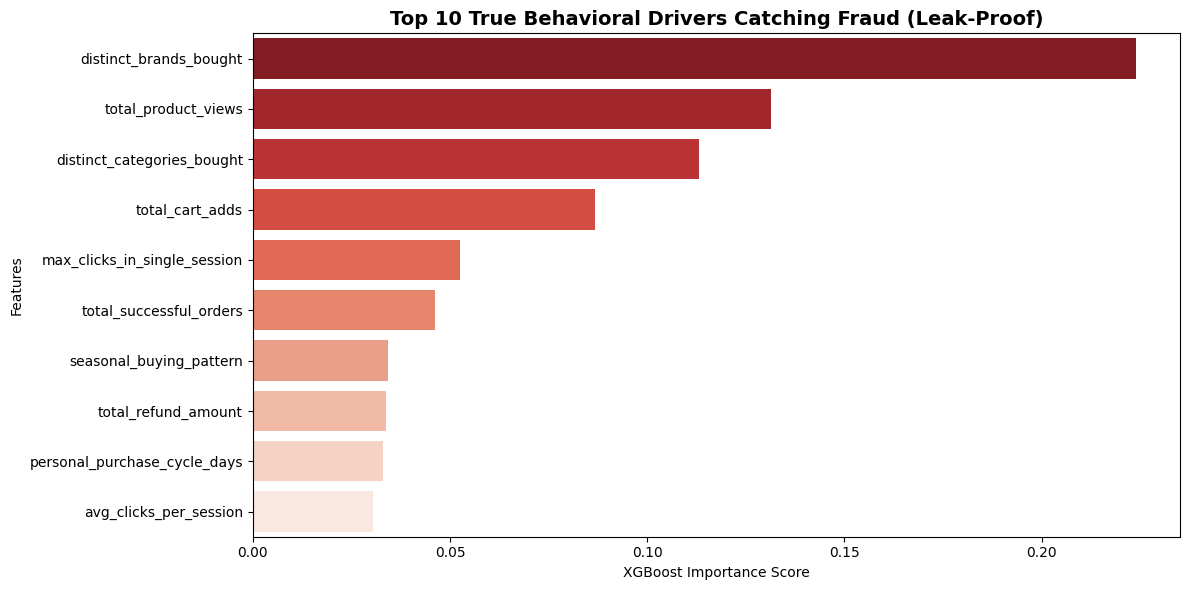

In [ ]:
# ==========================================
# 🤖 CELL 4: TRAINING THE GATEKEEPER AI (LEAK-PROOF XGBoost)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("⚔️ Step 1: Data ko X (Features) aur Y (Answers) mein tod rahe hain...")

# Y hai tera Target (Genuine=0, High-Risk=1)
y_fraud = fraud_df['is_fraud']

# X hain tere baaki bache 59 PURE features
X_fraud = fraud_df.drop('is_fraud', axis=1)

# Split data (80% Training, 20% Exam)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

print(f"   -> Padhai (Training) ke liye: {X_train_f.shape[0]} customers")
print(f"   -> Imtihaan (Testing) ke liye: {X_test_f.shape[0]} customers")

# AI ka dimaag balance karna (Frauds kam hain, isliye AI ko bolenge fraud pe zyada dhyan de)
fraud_ratio = float(np.sum(y_train_f == 0)) / np.sum(y_train_f == 1) if np.sum(y_train_f == 1) > 0 else 1

print("\n🤖 Step 2: Waking up the ASLI Gatekeeper AI... (Bina cheat sheet ke! Wait 1-2 mins)")

# Model Initialize karna
fraud_model = xgb.XGBClassifier(
    n_estimators=300,        # 300 Decision Trees
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=fraud_ratio, # 🔥 AI ko High-Risk pakadne par extra marks milenge
    random_state=42,
    eval_metric='logloss'
)

# AI Training start
fraud_model.fit(X_train_f, y_train_f)
print("✅ Training Complete!")

print("\n🎯 Step 3: Gatekeeper's Final Exam...")
# Test data par prediction
y_pred_f = fraud_model.predict(X_test_f)

# Report Card
print(f"\n🏆 ASLI GATEKEEPER ACCURACY: {accuracy_score(y_test_f, y_pred_f) * 100:.2f}%\n")
print("📊 FRAUD CATCHING REPORT CARD:")
print(classification_report(y_test_f, y_pred_f, target_names=['Genuine (0)', 'High-Risk (1)']))

# ==========================================
# 🧠 Step 4: AI ke Asli Hathiyar (Feature Importance)
# ==========================================
print("\n🔥 TOP 10 TRUE BEHAVIORS USED BY AI TO CATCH FRAUD:")
feature_importance_fraud = pd.DataFrame({
    'Feature': X_fraud.columns,
    'Importance': fraud_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Chart banana (Warning hatane ke liye 'hue' add kiya hai)
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_fraud.head(10), hue='Feature', palette='Reds_r', legend=False)
plt.title('Top 10 True Behavioral Drivers Catching Fraud (Leak-Proof)', fontsize=14, fontweight='bold')
plt.xlabel('XGBoost Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 4.1: PRE-AUDIT FOR CELL 5 (The Isolation Forest)
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 5 (Guard Dog) kya Input lega aur kya Naya Column banayega?\n")

# 1. Jo features Isolation Forest use karega (Speed ke liye Top 10)
top_10_fast_features = [
    'distinct_brands_bought',
    'total_product_views',
    'total_cart_adds',
    'distinct_categories_bought',
    'max_clicks_in_single_session',
    'total_refund_amount',
    'total_successful_orders',
    'personal_purchase_cycle_days',
    'avg_clicks_per_session',
    'logistics_experience_segment'
]

print(f"⚡ Guard Dog sirf in {len(top_10_fast_features)} columns ko sungh kar anomalies pakdega:")
for feat in top_10_fast_features:
    status = "✅ Present" if feat in fraud_df.columns else "❌ MISSING!"
    print(f"   - {feat} [{status}]")

print("\n🔮 Result: Cell 5 kya naya add karega?")
print("   -> Ek naya column banega: 'zero_day_anomaly_flag'")
print("   -> 0 = Normal / Safe Human")
print("   -> 1 = Zero-Day Bot / Anomaly (Ajeeb harkat karne wala)")

print("\n👁️ Data Sample (Guard Dog kya dekhega):")
display(fraud_df[top_10_fast_features].head(3))

🔍 AUDIT: Cell 5 (Guard Dog) kya Input lega aur kya Naya Column banayega?

⚡ Guard Dog sirf in 10 columns ko sungh kar anomalies pakdega:
   - distinct_brands_bought [✅ Present]
   - total_product_views [✅ Present]
   - total_cart_adds [✅ Present]
   - distinct_categories_bought [✅ Present]
   - max_clicks_in_single_session [✅ Present]
   - total_refund_amount [✅ Present]
   - total_successful_orders [✅ Present]
   - personal_purchase_cycle_days [✅ Present]
   - avg_clicks_per_session [✅ Present]
   - logistics_experience_segment [✅ Present]

🔮 Result: Cell 5 kya naya add karega?
   -> Ek naya column banega: 'zero_day_anomaly_flag'
   -> 0 = Normal / Safe Human
   -> 1 = Zero-Day Bot / Anomaly (Ajeeb harkat karne wala)

👁️ Data Sample (Guard Dog kya dekhega):


,distinct_brands_bought,total_product_views,total_cart_adds,distinct_categories_bought,max_clicks_in_single_session,total_refund_amount,total_successful_orders,personal_purchase_cycle_days,avg_clicks_per_session,logistics_experience_segment
0,0,0,0,0,0,0.0,0,0.0,0.0,4
1,0,0,0,0,0,0.0,0,0.0,0.0,4
2,0,1,1,0,5,18.5,0,0.0,5.0,2


In [ ]:
# ==========================================
# 🛑 CELL 5: GATEKEEPER V2 (Speed + Zero-Day Anomaly Detector)
# ==========================================
from sklearn.ensemble import IsolationForest
import pandas as pd
import numpy as np

print("⚡ STEP 1: Fixing Latency (Reducing features to TOP 10 Fast Features)...")

# Hum sirf wo 10 features le rahe hain jo AI ne Top 10 chart mein dikhaye
top_10_fast_features = [
    'distinct_brands_bought',
    'total_product_views',
    'total_cart_adds',
    'distinct_categories_bought',
    'max_clicks_in_single_session',
    'total_refund_amount',
    'total_successful_orders',
    'personal_purchase_cycle_days',
    'avg_clicks_per_session',
    'logistics_experience_segment'
]

X_fast = fraud_df[top_10_fast_features]

# ==========================================
# 🐕 STEP 2: The Guard Dog (Isolation Forest)
# ==========================================
print("\n🐕 STEP 2: Unleashing the Isolation Forest (Catching Zero-Day Bots)...")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02, # 2% anomalies assume kar rahe hain
    random_state=42,
    n_jobs=-1
)

# Kutta sungh raha hai
iso_forest.fit(X_fast)
anomaly_predictions = iso_forest.predict(X_fast)

# Save the flags
fraud_df['zero_day_anomaly_flag'] = np.where(anomaly_predictions == -1, 1, 0)

# ==========================================
# 📊 STEP 3: The Results
# ==========================================
total_zero_day = fraud_df['zero_day_anomaly_flag'].sum()
overlap_with_xgboost = fraud_df[(fraud_df['is_fraud'] == 1) & (fraud_df['zero_day_anomaly_flag'] == 1)].shape[0]
new_bots_found = fraud_df[(fraud_df['is_fraud'] == 0) & (fraud_df['zero_day_anomaly_flag'] == 1)].shape[0]

print("\n🏆 ISOLATION FOREST REPORT CARD:")
print(f"🚨 Total Anomalies (Weird Users) Caught: {total_zero_day}")
print(f"🤝 Old Frauds confirmed by both XGBoost & Isolation Forest: {overlap_with_xgboost}")
print(f"🤯 NEW ZERO-DAY BOTS FOUND (Jo SQL/XGBoost se bach gaye the!): {new_bots_found}")

⚡ STEP 1: Fixing Latency (Reducing features to TOP 10 Fast Features)...

🐕 STEP 2: Unleashing the Isolation Forest (Catching Zero-Day Bots)...

🏆 ISOLATION FOREST REPORT CARD:
🚨 Total Anomalies (Weird Users) Caught: 3223
🤝 Old Frauds confirmed by both XGBoost & Isolation Forest: 255
🤯 NEW ZERO-DAY BOTS FOUND (Jo SQL/XGBoost se bach gaye the!): 2968


In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 5.1: POST-AUDIT CELL 5 & PRE-AUDIT FOR CELL 6
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 6 (The Great Filter & Link 2 Prep) mein kya hone wala hai?\n")

# 1. Filter Check (Kachra Safai Analysis)
total_users = fraud_df.shape[0]
safe_mask = (fraud_df['is_fraud'] == 0) & (fraud_df['zero_day_anomaly_flag'] == 0)
safe_users = fraud_df[safe_mask].shape[0]
blocked_users = total_users - safe_users

print("🛡️ THE GREAT FILTER (Kitne log aage jayenge?):")
print(f"   -> Total Customers the: {total_users}")
print(f"   -> Blocked (Frauds + Bots): {blocked_users}")
print(f"   -> Safe Humans (Passed to Link 2): {safe_users}\n")

# 2. Target Generation Check
print("🎯 NEW TARGET CREATION ('is_returner'):")
print("   -> Jisne 'total_items_returned' > 0 kiya hai, wo 1 (Returner) banega, baaki 0 (Keeper).")

# 3. Leakage Drop Check
cols_to_drop_link2 = [
    'id', 'master_fraud_flag', 'scraper_abuse_risk', 'master_360_marketing_action',
    'churn_action_plan', 'solvency_action_plan', 'recursive_action_plan', 'complete_category_journey',
    'target_next_90d_spend', 'survival_probability_pct', 'ltv_segment', 'payback_order_number',
    'days_to_payback', 'rfm_code', 'recency_days', 'return_rate_percent',
    'total_items_returned', 'total_refund_amount'
]
print(f"\n🗑️ CHEAT CODES DROP ({len(cols_to_drop_link2)} Columns):")
print("   -> AI ko return ki aadat ka answer na mil jaye, isliye direct return stats uda rahe hain.")
print(cols_to_drop_link2)

🔍 AUDIT: Cell 6 (The Great Filter & Link 2 Prep) mein kya hone wala hai?

🛡️ THE GREAT FILTER (Kitne log aage jayenge?):
   -> Total Customers the: 161154
   -> Blocked (Frauds + Bots): 16439
   -> Safe Humans (Passed to Link 2): 144715

🎯 NEW TARGET CREATION ('is_returner'):
   -> Jisne 'total_items_returned' > 0 kiya hai, wo 1 (Returner) banega, baaki 0 (Keeper).

🗑️ CHEAT CODES DROP (18 Columns):
   -> AI ko return ki aadat ka answer na mil jaye, isliye direct return stats uda rahe hain.
['id', 'master_fraud_flag', 'scraper_abuse_risk', 'master_360_marketing_action', 'churn_action_plan', 'solvency_action_plan', 'recursive_action_plan', 'complete_category_journey', 'target_next_90d_spend', 'survival_probability_pct', 'ltv_segment', 'payback_order_number', 'days_to_payback', 'rfm_code', 'recency_days', 'return_rate_percent', 'total_items_returned', 'total_refund_amount']


In [ ]:
# ==========================================
# 🔗 CELL 6: DATA PREP FOR LINK 2 (Return Risk Predictor)
# ==========================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

print("🧹 STEP 1: The Great Filter (Kachra bahar nikal rahe hain)...")

# fraud_df mein jo safe mark hue the (XGBoost aur Isolation Forest dono se)
# 0 matlab Safe/Genuine
safe_mask = (fraud_df['is_fraud'] == 0) & (fraud_df['zero_day_anomaly_flag'] == 0)

# Original df_customers se sirf "Safe Humans" ka data nikalna
link2_df = df_customers[safe_mask].copy()

total_humans = link2_df.shape[0]
print(f"✅ Filter Done! Asli aur Safe insaan bache hain: {total_humans}")

print("\n🎯 STEP 2: Creating Target (Answer Sheet for Return Risk)...")
# Jisne zindagi mein 1 bhi item return kiya, wo 'Returner' (1) hai
link2_df['is_returner'] = np.where(link2_df['total_items_returned'].fillna(0) > 0, 1, 0)

# Check the balance
returners = (link2_df['is_returner'] == 1).sum()
keepers = (link2_df['is_returner'] == 0).sum()
print(f"   -> Samaan Rakhne Wale (Keepers - 0): {keepers}")
print(f"   -> Samaan Wapas Karne Wale (Returners - 1): {returners}")

print("\n🚫 STEP 3: Dropping Cheat Codes (Leakage Prevention)...")
# AI ko cheating se bachane ke liye direct return aur useless columns uda rahe hain
cols_to_drop_link2 = [
    'id', 'master_fraud_flag', 'scraper_abuse_risk', 'master_360_marketing_action',
    'churn_action_plan', 'solvency_action_plan', 'recursive_action_plan', 'complete_category_journey',
    'target_next_90d_spend', 'survival_probability_pct', 'ltv_segment', 'payback_order_number',
    'days_to_payback', 'rfm_code', 'recency_days',

    # 🔥 THE CHEAT CODES FOR LINK 2 (AI ko inke bina predict karna hoga) 🔥
    'return_rate_percent',
    'total_items_returned',
    'total_refund_amount'
]

return_risk_df = link2_df.drop(columns=cols_to_drop_link2, errors='ignore')

print("\n🛠️ STEP 4: Math Conversion (English to Numbers)...")
cat_cols_link2 = return_risk_df.select_dtypes(include=['object', 'string']).columns
label_encoders_link2 = {}

for col in cat_cols_link2:
    return_risk_df[col] = return_risk_df[col].fillna('Unknown').astype(str)
    le = LabelEncoder()
    return_risk_df[col] = le.fit_transform(return_risk_df[col])
    label_encoders_link2[col] = le

numeric_cols_link2 = return_risk_df.columns.difference(cat_cols_link2)
for col in numeric_cols_link2:
    return_risk_df[col] = pd.to_numeric(return_risk_df[col], errors='coerce').fillna(0)

print("\n✅ Link 2 Data Preparation 100% Complete! Ready for AI.")
print(f"📊 Features passing to Return Risk AI (X): {return_risk_df.shape[1] - 1}")

🧹 STEP 1: The Great Filter (Kachra bahar nikal rahe hain)...
✅ Filter Done! Asli aur Safe insaan bache hain: 144715

🎯 STEP 2: Creating Target (Answer Sheet for Return Risk)...
   -> Samaan Rakhne Wale (Keepers - 0): 124829
   -> Samaan Wapas Karne Wale (Returners - 1): 19886

🚫 STEP 3: Dropping Cheat Codes (Leakage Prevention)...

🛠️ STEP 4: Math Conversion (English to Numbers)...

✅ Link 2 Data Preparation 100% Complete! Ready for AI.
📊 Features passing to Return Risk AI (X): 63


In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 6.1: POST-AUDIT CELL 6 & PRE-AUDIT FOR CELL 7
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 7 (Return Risk AI) kya Input lega?\n")

target_col_link2 = 'is_returner'

print(f"🎯 THE TARGET (Y) -> AI kya predict karna seekhega:")
print(f"   Column Name: '{target_col_link2}'")
print(f"   -> Keepers (Samaan rakhne wale - 0): {(return_risk_df[target_col_link2] == 0).sum()}")
print(f"   -> Returners (Wapas karne wale - 1): {(return_risk_df[target_col_link2] == 1).sum()}\n")

features_cols_link2 = [col for col in return_risk_df.columns if col not in [target_col_link2, 'is_fraud']]

print(f"🤖 THE FEATURES (X) -> AI kin {len(features_cols_link2)} columns ko padh kar return risk pakdega:")
print(features_cols_link2)

print("\n👁️ Data Type Check (Ensuring AI-Ready Numbers):")
string_cols_link2 = return_risk_df.select_dtypes(include=['object', 'string']).columns.tolist()
if len(string_cols_link2) == 0:
    print("✅ Sab kuch successfully Numbers mein convert ho chuka hai! No leakage found.")
else:
    print(f"⚠️ Warning: Yeh columns abhi bhi text hain: {string_cols_link2}")

🔍 AUDIT: Cell 7 (Return Risk AI) kya Input lega?

🎯 THE TARGET (Y) -> AI kya predict karna seekhega:
   Column Name: 'is_returner'
   -> Keepers (Samaan rakhne wale - 0): 124829
   -> Returners (Wapas karne wale - 1): 19886

🤖 THE FEATURES (X) -> AI kin 62 columns ko padh kar return risk pakdega:
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_persona', 'total_revenue', 'total_successful_orders', 'average_order_value', 'profit_margin_percent', 'total_absolute_profit', 'profitability_segment', 'spending_habit_segment', 'is_discount_hunter', 'personal_purchase_cycle_days', 'days_since_last_order', 'l365_total_spend', 'l365_total_orders', 'discount_dependency_ratio', 'highest_price_paid', 'premium_items_bought', 'mid_range_items_bought', 'budget_items_bought', 'top_favorite_brand', 'top_favorite_category', 'brand_loyalty_segment', 'primary_traffic_source', 'browsing_perso

⚔️ Step 1: Data ko X (Features) aur Y (Answers) mein tod rahe hain...
⚖️ AI Balancing Act: 1 Returner pakadne par AI ko 6.28x zyada marks milenge!

🤖 Step 2: Waking up the Return Risk AI... (Wait 1-2 mins)
✅ Training Complete!

🎯 Step 3: Return Risk AI's Final Exam...

📊 RETURN PREDICTION REPORT CARD:
               precision    recall  f1-score   support

  Keepers (0)       1.00      1.00      1.00     24966
Returners (1)       0.99      0.99      0.99      3977

     accuracy                           1.00     28943
    macro avg       0.99      1.00      0.99     28943
 weighted avg       1.00      1.00      1.00     28943


🔥 TOP 10 REASONS WHY CUSTOMERS RETURN ITEMS:


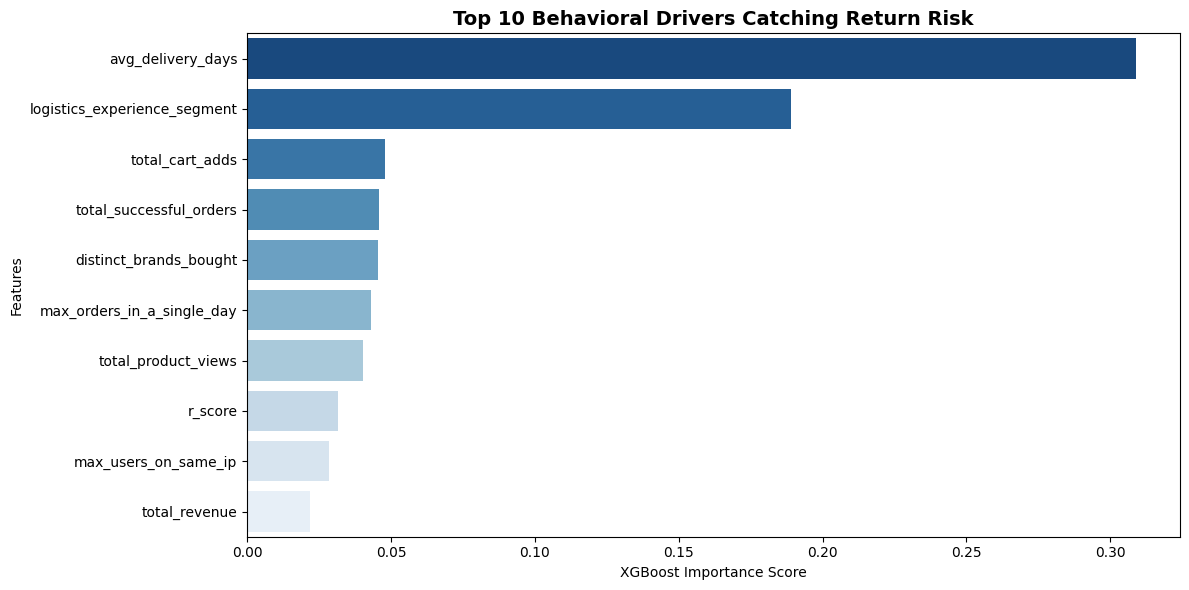

In [ ]:
# ==========================================
# 🤖 CELL 7: TRAINING LINK 2 (Return Risk Predictor)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("⚔️ Step 1: Data ko X (Features) aur Y (Answers) mein tod rahe hain...")

# Y hai tera Target (Keeper=0, Returner=1)
y_return = return_risk_df['is_returner']

# X hain tere Features (Target aur useless 'is_fraud' ko uda rahe hain)
X_return = return_risk_df.drop(columns=['is_returner', 'is_fraud'], errors='ignore')

# Split data (80% Training, 20% Exam)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_return, y_return, test_size=0.2, random_state=42, stratify=y_return
)

# Imbalance ko theek karna (Weightage for Returners)
return_ratio = float(np.sum(y_train_r == 0)) / np.sum(y_train_r == 1)

print(f"⚖️ AI Balancing Act: 1 Returner pakadne par AI ko {return_ratio:.2f}x zyada marks milenge!\n")
print("🤖 Step 2: Waking up the Return Risk AI... (Wait 1-2 mins)")

# Model Initialize karna
return_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=return_ratio, # 🔥 THE STEROID FOR IMBALANCED DATA
    random_state=42,
    eval_metric='logloss'
)

# AI Training start
return_model.fit(X_train_r, y_train_r)
print("✅ Training Complete!")

print("\n🎯 Step 3: Return Risk AI's Final Exam...")
# Test data par prediction
y_pred_r = return_model.predict(X_test_r)

# Report Card
print("\n📊 RETURN PREDICTION REPORT CARD:")
print(classification_report(y_test_r, y_pred_r, target_names=['Keepers (0)', 'Returners (1)']))

# ==========================================
# 🧠 Step 4: AI ke Asli Hathiyar (Feature Importance)
# ==========================================
print("\n🔥 TOP 10 REASONS WHY CUSTOMERS RETURN ITEMS:")
feature_importance_return = pd.DataFrame({
    'Feature': X_return.columns,
    'Importance': return_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_return.head(10), hue='Feature', palette='Blues_r', legend=False)
plt.title('Top 10 Behavioral Drivers Catching Return Risk', fontsize=14, fontweight='bold')
plt.xlabel('XGBoost Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 7.1: POST-AUDIT CELL 7 & PRE-AUDIT FOR CELL 8 (FIXED)
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 8 (The Chaining & Churn Prep) mein kya hone wala hai?\n")

# 1. Chaining Check
print("🔗 THE AI CHAINING (Link 2 ➔ Link 3):")
print("   -> Ek Naya Column Banega: 'predicted_return_risk'")
print("   -> Kahan se aayega?: Cell 7 ka AI model probability (0 se 1 ke beech) nikal kar isme dalega.\n")

# 2. Target Generation Check
print("🎯 NEW TARGET CREATION ('is_churned'):")
print("   -> Asliyat mein kaun bhag gaya? Iska Formula:")
print("   -> Agar customer apne 'personal_purchase_cycle' se 1.5x guna zyada late hai AUR website par 30 din se nahi aaya = Churned (1) warna Active (0).\n")

# 3. Leakage Drop Check
cols_to_drop_link3 = [
    'days_since_last_order',
    'days_since_last_visit',
    'personal_purchase_cycle_days',
    'rfm_segment',
    'lifecycle_segment',
    'r_score',
    'is_returner'
]
print(f"🗑️ CHURN CHEAT CODES DROP ({len(cols_to_drop_link3)} Columns):")
print("   -> AI ko cheating se rokne ke liye time-based details chheen lenge.")
print(cols_to_drop_link3)

# 4. 🔥 THE MISSING PIECE (What goes to AI)
# Pichle features me se cheat codes hataye, aur naya 'predicted_return_risk' joda
features_used = [col for col in return_risk_df.columns if col not in cols_to_drop_link3 and col != 'is_fraud']
features_used.append('predicted_return_risk')

print(f"\n🤖 FINAL FEATURES FOR CHURN AI ({len(features_used)} Columns Use Honge):")
print(features_used)

🔍 AUDIT: Cell 8 (The Chaining & Churn Prep) mein kya hone wala hai?

🔗 THE AI CHAINING (Link 2 ➔ Link 3):
   -> Ek Naya Column Banega: 'predicted_return_risk'
   -> Kahan se aayega?: Cell 7 ka AI model probability (0 se 1 ke beech) nikal kar isme dalega.

🎯 NEW TARGET CREATION ('is_churned'):
   -> Asliyat mein kaun bhag gaya? Iska Formula:
   -> Agar customer apne 'personal_purchase_cycle' se 1.5x guna zyada late hai AUR website par 30 din se nahi aaya = Churned (1) warna Active (0).

🗑️ CHURN CHEAT CODES DROP (7 Columns):
   -> AI ko cheating se rokne ke liye time-based details chheen lenge.
['days_since_last_order', 'days_since_last_visit', 'personal_purchase_cycle_days', 'rfm_segment', 'lifecycle_segment', 'r_score', 'is_returner']

🤖 FINAL FEATURES FOR CHURN AI (57 Columns Use Honge):
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_persona', 'total_revenue', 'tota

In [ ]:
# ==========================================
# 🔗 CELL 8: DATA PREP & CHAINING FOR LINK 3 (Churn Risk)
# ==========================================
import numpy as np
import pandas as pd

print("🔄 STEP 1: Executing Multivariate Chaining (Bringing Link 2 Knowledge)...")
# Start with Link 2's cleaned feature set
link3_df = return_risk_df.copy()

# 🔥 THE CHAIN: Link 2 ka AI predict kar raha hai ki inka Return Probability kitna hai
link3_df['predicted_return_risk'] = return_model.predict_proba(X_return)[:, 1]

print("🎯 STEP 2: Creating Target (Answer Sheet for Churn)...")
# TERA MASTER LOGIC: Calculating Churn based on Cycle & Recency
safe_cycle = np.where(link3_df['personal_purchase_cycle_days'] > 0, link3_df['personal_purchase_cycle_days'], 90)

link3_df['is_churned'] = np.where(
    (link3_df['days_since_last_order'] > (safe_cycle * 1.5)) &
    (link3_df['days_since_last_visit'] > 30),
    1, 0
)

churners = (link3_df['is_churned'] == 1).sum()
actives = (link3_df['is_churned'] == 0).sum()
print(f"   -> Active Customers (0): {actives}")
print(f"   -> Churned / Lost Customers (1): {churners}")

print("\n🚫 STEP 3: Dropping Churn Cheat Codes (Leakage Prevention)...")
# Drop Time-based and Text-based leaks
cols_to_drop_link3 = [
    'days_since_last_order',
    'days_since_last_visit',
    'personal_purchase_cycle_days',
    'rfm_segment',
    'lifecycle_segment',
    'r_score',
    'is_returner' # Dropping static label, keeping AI probability instead
]

churn_risk_df = link3_df.drop(columns=cols_to_drop_link3, errors='ignore')

print("\n✅ Link 3 Data Preparation 100% Complete! Ready for AI.")
print(f"📊 Features passing to Churn Risk AI (X): {churn_risk_df.shape[1] - 1}")

🔄 STEP 1: Executing Multivariate Chaining (Bringing Link 2 Knowledge)...
🎯 STEP 2: Creating Target (Answer Sheet for Churn)...
   -> Active Customers (0): 61051
   -> Churned / Lost Customers (1): 83664

🚫 STEP 3: Dropping Churn Cheat Codes (Leakage Prevention)...

✅ Link 3 Data Preparation 100% Complete! Ready for AI.
📊 Features passing to Churn Risk AI (X): 58


In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 8.1: POST-AUDIT CELL 8 & PRE-AUDIT FOR CELL 9
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 9 (Churn Risk AI) kya Input lega?\n")

target_col_link3 = 'is_churned'

print(f"🎯 THE TARGET (Y) -> AI kya predict karna seekhega:")
print(f"   Column Name: '{target_col_link3}'")
print(f"   -> Active Customers (Rukne wale - 0): {(churn_risk_df[target_col_link3] == 0).sum()}")
print(f"   -> Churned / Lost (Bhagne wale - 1): {(churn_risk_df[target_col_link3] == 1).sum()}\n")

# AI ke paas features kya jayenge (Target ko chhod kar baaki sab)
features_cols_link3 = [col for col in churn_risk_df.columns if col != target_col_link3]

print(f"🤖 THE FEATURES (X) -> AI kin {len(features_cols_link3)} columns ko padh kar bhagne ka risk pakdega:")
print(features_cols_link3)

print("\n👁️ Data Type Check (Ensuring AI-Ready Numbers):")
string_cols_link3 = churn_risk_df.select_dtypes(include=['object', 'string']).columns.tolist()
if len(string_cols_link3) == 0:
    print("✅ Sab kuch successfully Numbers mein convert ho chuka hai! No leakage found. Ready for Churn AI.")
else:
    print(f"⚠️ Warning: Yeh columns abhi bhi text hain: {string_cols_link3}")

🔍 AUDIT: Cell 9 (Churn Risk AI) kya Input lega?

🎯 THE TARGET (Y) -> AI kya predict karna seekhega:
   Column Name: 'is_churned'
   -> Active Customers (Rukne wale - 0): 61051
   -> Churned / Lost (Bhagne wale - 1): 83664

🤖 THE FEATURES (X) -> AI kin 58 columns ko padh kar bhagne ka risk pakdega:
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_persona', 'total_revenue', 'total_successful_orders', 'average_order_value', 'profit_margin_percent', 'total_absolute_profit', 'profitability_segment', 'spending_habit_segment', 'is_discount_hunter', 'l365_total_spend', 'l365_total_orders', 'discount_dependency_ratio', 'highest_price_paid', 'premium_items_bought', 'mid_range_items_bought', 'budget_items_bought', 'top_favorite_brand', 'top_favorite_category', 'brand_loyalty_segment', 'primary_traffic_source', 'browsing_persona', 'preferred_shopping_time', 'preferred_shopping_day'

⚔️ Step 1: Splitting Data for Churn Predictor...

🤖 Step 2: Waking up the Churn Risk AI... (Wait 1-2 mins)
✅ Training Complete!

🎯 Step 3: Churn Risk AI's Final Exam...

📊 CHURN PREDICTION REPORT CARD:
              precision    recall  f1-score   support

  Active (0)       0.87      0.89      0.88     12210
 Churned (1)       0.92      0.90      0.91     16733

    accuracy                           0.90     28943
   macro avg       0.89      0.90      0.90     28943
weighted avg       0.90      0.90      0.90     28943


🔥 TOP 10 REASONS WHY CUSTOMERS ABANDON THE APP:


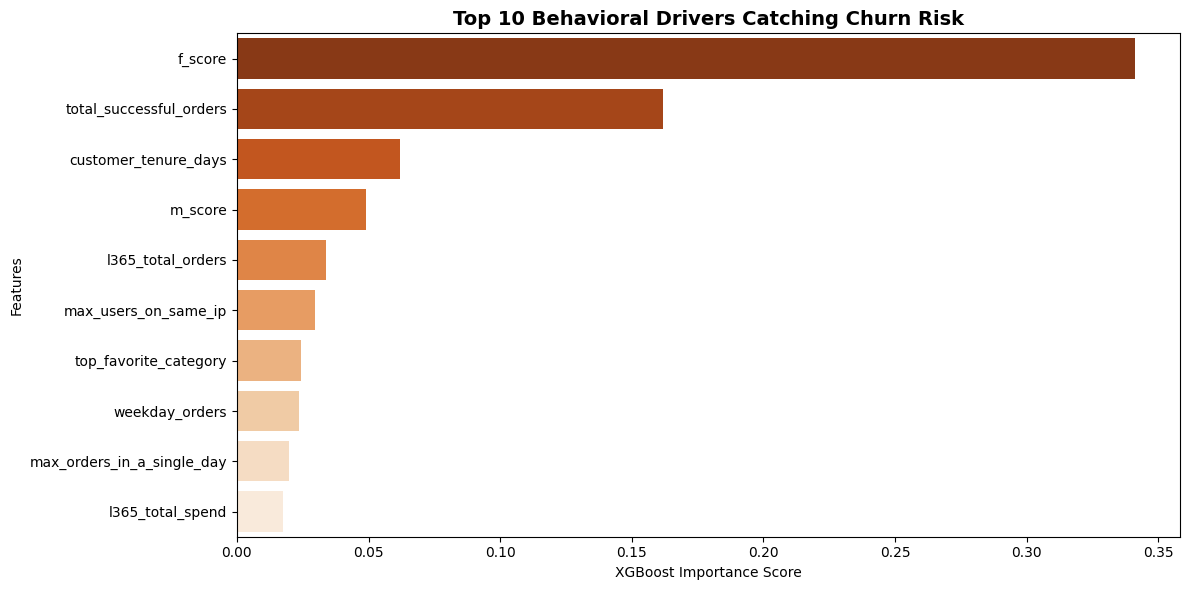

In [ ]:
# ==========================================
# 🤖 CELL 9: TRAINING LINK 3 (Churn Predictor)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("⚔️ Step 1: Splitting Data for Churn Predictor...")

y_churn = churn_risk_df['is_churned']
X_churn = churn_risk_df.drop(columns=['is_churned'], errors='ignore')

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

print("\n🤖 Step 2: Waking up the Churn Risk AI... (Wait 1-2 mins)")
# Balance the data
churn_ratio = float(np.sum(y_train_c == 0)) / np.sum(y_train_c == 1) if np.sum(y_train_c == 1) > 0 else 1

churn_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=churn_ratio,
    random_state=42,
    eval_metric='logloss'
)

churn_model.fit(X_train_c, y_train_c)
print("✅ Training Complete!")

print("\n🎯 Step 3: Churn Risk AI's Final Exam...")
y_pred_c = churn_model.predict(X_test_c)

print("\n📊 CHURN PREDICTION REPORT CARD:")
print(classification_report(y_test_c, y_pred_c, target_names=['Active (0)', 'Churned (1)']))

# ==========================================
# 🧠 Step 4: AI ke Asli Hathiyar (Feature Importance)
# ==========================================
print("\n🔥 TOP 10 REASONS WHY CUSTOMERS ABANDON THE APP:")
feature_importance_churn = pd.DataFrame({
    'Feature': X_churn.columns,
    'Importance': churn_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_churn.head(10), hue='Feature', palette='Oranges_r', legend=False)
plt.title('Top 10 Behavioral Drivers Catching Churn Risk', fontsize=14, fontweight='bold')
plt.xlabel('XGBoost Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 9.1: POST-AUDIT CELL 9 & PRE-AUDIT FOR CELL 10
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 10 (LTV Forecaster Prep) mein kya hone wala hai?\n")

# 1. Chaining Check
print("🔗 THE AI CHAINING (Link 3 ➔ Link 4):")
print("   -> Ek Naya Column Banega: 'predicted_churn_risk'")
print("   -> Kahan se aayega?: Cell 9 ka AI (Churn Model) probability (bhagne ka chance %) nikal kar isme dalega.\n")

# 2. Target Retrieval Check
print("🎯 TARGET RETRIEVAL ('target_next_90d_spend'):")
print("   -> Target: Agle 90 din mein customer kitne Dollars ($) kharach karega.")
print("   -> Yeh column humne shuru mein uda diya tha, ab isko original 'df_customers' se wapas memory mein layenge.\n")

# 3. Leakage Drop Check
cols_to_drop_link4 = ['is_churned']
print(f"🗑️ LTV CHEAT CODES DROP ({len(cols_to_drop_link4)} Columns):")
print("   -> AI ko cheating se rokne ke liye hum hard label ('is_churned') uda denge.")
print("   -> Uski jagah sirf AI ki probability ('predicted_churn_risk') use hogi.")
print(cols_to_drop_link4)

# 4. Final Features Check
features_used_ltv = [col for col in churn_risk_df.columns if col not in cols_to_drop_link4]
features_used_ltv.append('predicted_churn_risk')

print(f"\n🤖 FINAL FEATURES FOR LTV AI ({len(features_used_ltv)} Columns Use Honge):")
print(features_used_ltv)

🔍 AUDIT: Cell 10 (LTV Forecaster Prep) mein kya hone wala hai?

🔗 THE AI CHAINING (Link 3 ➔ Link 4):
   -> Ek Naya Column Banega: 'predicted_churn_risk'
   -> Kahan se aayega?: Cell 9 ka AI (Churn Model) probability (bhagne ka chance %) nikal kar isme dalega.

🎯 TARGET RETRIEVAL ('target_next_90d_spend'):
   -> Target: Agle 90 din mein customer kitne Dollars ($) kharach karega.
   -> Yeh column humne shuru mein uda diya tha, ab isko original 'df_customers' se wapas memory mein layenge.

🗑️ LTV CHEAT CODES DROP (1 Columns):
   -> AI ko cheating se rokne ke liye hum hard label ('is_churned') uda denge.
   -> Uski jagah sirf AI ki probability ('predicted_churn_risk') use hogi.
['is_churned']

🤖 FINAL FEATURES FOR LTV AI (59 Columns Use Honge):
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_persona', 'total_revenue', 'total_successful_orders', 'average_order_value', 'prof

In [ ]:
# ==========================================
# 🔗 CELL 10: DATA PREP & CHAINING FOR LINK 4 (LTV Forecaster)
# ==========================================
import pandas as pd
import numpy as np

print("🔄 STEP 1: Executing Multivariate Chaining (Bringing Link 3 Knowledge)...")
# Start with Link 3's dataset
link4_df = churn_risk_df.copy()

# 🔥 THE CHAIN: Link 3 ka AI predict kar raha hai ki Churn Probability (Bhagne ka risk) kitna hai
link4_df['predicted_churn_risk'] = churn_model.predict_proba(X_churn)[:, 1]

print("🎯 STEP 2: Retrieving the Target (Answer Sheet for Dollars)...")
# Humne target_next_90d_spend ko pehle uda diya tha, ab usko original df_customers se wapas la rahe hain
link4_df['target_next_90d_spend'] = df_customers.loc[link4_df.index, 'target_next_90d_spend']

# Null values (jisne kuch kharach nahi karna) ko $0 kar dete hain
link4_df['target_next_90d_spend'] = pd.to_numeric(link4_df['target_next_90d_spend'], errors='coerce').fillna(0)

print("\n🚫 STEP 3: Dropping Cheats (Leakage Prevention)...")
# 'is_churned' ek hard rule tha, AI ko iski jagah 'predicted_churn_risk' probability de di hai, toh isko uda denge.
cols_to_drop_link4 = ['is_churned']
ltv_df = link4_df.drop(columns=cols_to_drop_link4, errors='ignore')

print("\n✅ Link 4 Data Preparation 100% Complete! Ready for AI Regression.")
print(f"📊 Features passing to LTV AI (X): {ltv_df.shape[1] - 1}")

🔄 STEP 1: Executing Multivariate Chaining (Bringing Link 3 Knowledge)...
🎯 STEP 2: Retrieving the Target (Answer Sheet for Dollars)...

🚫 STEP 3: Dropping Cheats (Leakage Prevention)...

✅ Link 4 Data Preparation 100% Complete! Ready for AI Regression.
📊 Features passing to LTV AI (X): 59


In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 10.1: POST-AUDIT CELL 10 & PRE-AUDIT FOR CELL 11
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 11 (LTV Predictor AI) kya Input lega?\n")

target_col_link4 = 'target_next_90d_spend'

print(f"🎯 THE TARGET (Y) -> AI kya predict karna seekhega:")
print(f"   Column Name: '{target_col_link4}'")
print("   -> Yeh Classification (0/1) nahi hai, yeh Regression (Continuous $) hai.")
print(f"   -> Average Target Spend: ${ltv_df[target_col_link4].mean():.2f}")
print(f"   -> Maximum Target Spend: ${ltv_df[target_col_link4].max():.2f}\n")

features_cols_link4 = [col for col in ltv_df.columns if col != target_col_link4]

print(f"🤖 THE FEATURES (X) -> AI kin {len(features_cols_link4)} columns ko padh kar future dollars ($) predict karega:")
print(features_cols_link4)

print("\n👁️ Data Type Check (Ensuring AI-Ready Numbers):")
string_cols_link4 = ltv_df.select_dtypes(include=['object', 'string']).columns.tolist()
if len(string_cols_link4) == 0:
    print("✅ Sab kuch successfully Numbers mein convert ho chuka hai! Ready for LTV XGBRegressor.")
else:
    print(f"⚠️ Warning: Yeh columns abhi bhi text hain: {string_cols_link4}")

🔍 AUDIT: Cell 11 (LTV Predictor AI) kya Input lega?

🎯 THE TARGET (Y) -> AI kya predict karna seekhega:
   Column Name: 'target_next_90d_spend'
   -> Yeh Classification (0/1) nahi hai, yeh Regression (Continuous $) hai.
   -> Average Target Spend: $27.98
   -> Maximum Target Spend: $1467.76

🤖 THE FEATURES (X) -> AI kin 59 columns ko padh kar future dollars ($) predict karega:
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_persona', 'total_revenue', 'total_successful_orders', 'average_order_value', 'profit_margin_percent', 'total_absolute_profit', 'profitability_segment', 'spending_habit_segment', 'is_discount_hunter', 'l365_total_spend', 'l365_total_orders', 'discount_dependency_ratio', 'highest_price_paid', 'premium_items_bought', 'mid_range_items_bought', 'budget_items_bought', 'top_favorite_brand', 'top_favorite_category', 'brand_loyalty_segment', 'primary_traffic

⚔️ Step 1: Splitting Data for LTV Predictor...

🤖 Step 2: Waking up the LTV XGBoost Regressor... (Wait 1-2 mins)
✅ Training Complete!

🎯 Step 3: LTV Forecaster's Final Exam...

📊 LTV PREDICTION REPORT CARD:
💵 Mean Absolute Error (MAE): $10.21
   -> (Iska matlab AI ki prediction average $10.21 upar-neeche hoti hai)
📈 R-Squared (R2) Score: 89.08%

🔥 TOP 10 REASONS DRIVING CUSTOMER FUTURE SPEND ($):


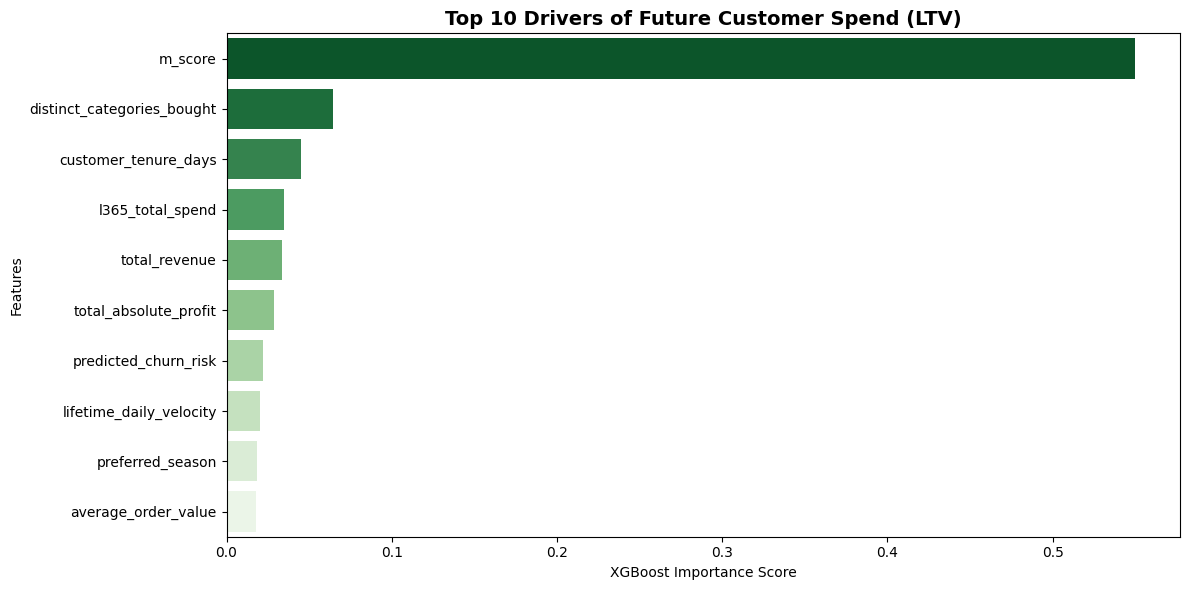

In [ ]:
# ==========================================
# 🤖 CELL 11: TRAINING LINK 4 (LTV Predictor - Regression)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("⚔️ Step 1: Splitting Data for LTV Predictor...")

# Y hai tera Target (Dollars $)
y_ltv = ltv_df['target_next_90d_spend']

# X hain tere Features (Total 59 features)
X_ltv = ltv_df.drop(columns=['target_next_90d_spend'], errors='ignore')

# Regression mein stratify nahi hota (kyunki classes nahi, continuous numbers hain)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_ltv, y_ltv, test_size=0.2, random_state=42
)

print("\n🤖 Step 2: Waking up the LTV XGBoost Regressor... (Wait 1-2 mins)")
# DHYAN DE: Yahan XGBRegressor use ho raha hai, Classifier nahi!
ltv_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mae' # MAE = Mean Absolute Error
)

ltv_model.fit(X_train_l, y_train_l)
print("✅ Training Complete!")

print("\n🎯 Step 3: LTV Forecaster's Final Exam...")
y_pred_l = ltv_model.predict(X_test_l)

# Negatives ko 0 kar dete hain (Koi customer minus mein paise nahi dega)
y_pred_l = np.clip(y_pred_l, 0, None)

# Report Card (Regression Metrics)
mae = mean_absolute_error(y_test_l, y_pred_l)
r2 = r2_score(y_test_l, y_pred_l)

print(f"\n📊 LTV PREDICTION REPORT CARD:")
print(f"💵 Mean Absolute Error (MAE): ${mae:.2f}")
print(f"   -> (Iska matlab AI ki prediction average ${mae:.2f} upar-neeche hoti hai)")
print(f"📈 R-Squared (R2) Score: {r2 * 100:.2f}%")

# ==========================================
# 🧠 Step 4: AI ke Asli Hathiyar (Feature Importance)
# ==========================================
print("\n🔥 TOP 10 REASONS DRIVING CUSTOMER FUTURE SPEND ($):")
feature_importance_ltv = pd.DataFrame({
    'Feature': X_ltv.columns,
    'Importance': ltv_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_ltv.head(10), hue='Feature', palette='Greens_r', legend=False)
plt.title('Top 10 Drivers of Future Customer Spend (LTV)', fontsize=14, fontweight='bold')
plt.xlabel('XGBoost Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 11.1: POST-AUDIT CELL 11 & PRE-AUDIT FOR CELL 12
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 12 (The Reality Pivot & Promo Prep) mein kya hone wala hai?\n")

# 1. Chaining Check
print("🔗 THE AI CHAINING (Link 4 ➔ Link 5):")
print("   -> Ek Naya Column Banega: 'predicted_ltv'")
print("   -> Kahan se aayega?: Cell 11 ka AI predicted Dollars ($) nikal kar isme dalega.\n")

# 2. Target Generation Check
print("🎯 NEW TARGET CREATION ('promo_segment'):")
print("   -> Target: Customer ki price sensitivity (Aukat) kya hai?")
print("   -> 0 = Premium Buyer (AOV >= $80)")
print("   -> 1 = Mid-Range Buyer (AOV $40 - $79)")
print("   -> 2 = Budget Buyer (AOV < $40)\n")

# 3. Leakage Drop Check (MASSIVE DROP)
cols_to_drop_link5 = [
    'average_order_value', 'total_revenue', 'total_absolute_profit',
    'highest_price_paid', 'budget_items_bought', 'mid_range_items_bought',
    'premium_items_bought', 'spending_habit_segment',
    'discount_dependency_ratio', 'is_discount_hunter', 'discount_leech_ratio',
    'target_next_90d_spend'
]
print(f"🗑️ MASSIVE CHEAT CODES DROP ({len(cols_to_drop_link5)} Columns):")
print("   -> Kyunki humara naya Target 'AOV/Price' se bana hai, humein paise (revenue/price) wale SAARE columns udane padenge!")
print(cols_to_drop_link5)

# 4. Final Features Check
features_used_promo = [col for col in ltv_df.columns if col not in cols_to_drop_link5]
features_used_promo.append('predicted_ltv')

print(f"\n🤖 FINAL FEATURES FOR SENSITIVITY AI ({len(features_used_promo)} Columns Use Honge):")
print(features_used_promo)

🔍 AUDIT: Cell 12 (The Reality Pivot & Promo Prep) mein kya hone wala hai?

🔗 THE AI CHAINING (Link 4 ➔ Link 5):
   -> Ek Naya Column Banega: 'predicted_ltv'
   -> Kahan se aayega?: Cell 11 ka AI predicted Dollars ($) nikal kar isme dalega.

🎯 NEW TARGET CREATION ('promo_segment'):
   -> Target: Customer ki price sensitivity (Aukat) kya hai?
   -> 0 = Premium Buyer (AOV >= $80)
   -> 1 = Mid-Range Buyer (AOV $40 - $79)
   -> 2 = Budget Buyer (AOV < $40)

🗑️ MASSIVE CHEAT CODES DROP (12 Columns):
   -> Kyunki humara naya Target 'AOV/Price' se bana hai, humein paise (revenue/price) wale SAARE columns udane padenge!
['average_order_value', 'total_revenue', 'total_absolute_profit', 'highest_price_paid', 'budget_items_bought', 'mid_range_items_bought', 'premium_items_bought', 'spending_habit_segment', 'discount_dependency_ratio', 'is_discount_hunter', 'discount_leech_ratio', 'target_next_90d_spend']

🤖 FINAL FEATURES FOR SENSITIVITY AI (49 Columns Use Honge):
['user_age', 'user_gender', 'use

In [ ]:
# ==========================================
# 🔗 CELL 12: DATA PREP & CHAINING FOR LINK 5 (THE REALITY PIVOT)
# ==========================================
import pandas as pd
import numpy as np

print("🔄 STEP 1: The Ultimate Chaining (Bringing Link 2, 3 & 4 Knowledge)...")
link5_df = ltv_df.copy()

# 🔥 THE CHAIN: Link 4's predicted LTV Dollars
predicted_dollars = ltv_model.predict(X_ltv)
link5_df['predicted_ltv'] = np.clip(predicted_dollars, 0, None)

print("🎯 STEP 2: The Dataset Reality Check (Creating Price Sensitivity Target)...")
# Asliyat: TheLook dataset mein discounts nahi hote!
# Fix: Hum 'Price Sensitivity' (Aukat) predict karenge LLM ke liye.
pure_aov = pd.to_numeric(df_customers.loc[link5_df.index, 'average_order_value'], errors='coerce').fillna(0)

conditions = [
    (pure_aov >= 80),                   # 0: Premium Buyer (High Aukat)
    (pure_aov >= 40) & (pure_aov < 80), # 1: Mid-Range
    (pure_aov < 40)                     # 2: Budget Buyer (Price Sensitive)
]
choices = [0, 1, 2]
link5_df['promo_segment'] = np.select(conditions, choices, default=1)

print("\n🚫 STEP 3: Dropping Cheats (Massive Leakage Prevention)...")
# Kyunki target AOV se bana hai, saare Price aur Revenue columns udane padenge!
cols_to_drop_link5 = [
    'average_order_value', 'total_revenue', 'total_absolute_profit',
    'highest_price_paid', 'budget_items_bought', 'mid_range_items_bought',
    'premium_items_bought', 'spending_habit_segment',
    'discount_dependency_ratio', 'is_discount_hunter', 'discount_leech_ratio',
    'target_next_90d_spend'
]
promo_df = link5_df.drop(columns=cols_to_drop_link5, errors='ignore')

print("\n✅ Link 5 Data Preparation 100% Complete!")
print(f"📊 Features passing to Sensitivity AI (X): {promo_df.shape[1] - 1}")
print("\n👥 SEGMENT BREAKDOWN (Premium vs Budget):")
print(promo_df['promo_segment'].value_counts().sort_index().rename(index={0: 'Premium Buyer (0)', 1: 'Mid-Range (1)', 2: 'Budget Buyer (2)'}))

🔄 STEP 1: The Ultimate Chaining (Bringing Link 2, 3 & 4 Knowledge)...
🎯 STEP 2: The Dataset Reality Check (Creating Price Sensitivity Target)...

🚫 STEP 3: Dropping Cheats (Massive Leakage Prevention)...

✅ Link 5 Data Preparation 100% Complete!
📊 Features passing to Sensitivity AI (X): 49

👥 SEGMENT BREAKDOWN (Premium vs Budget):
promo_segment
Premium Buyer (0)    62527
Mid-Range (1)        38216
Budget Buyer (2)     43972
Name: count, dtype: int64


In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 12.1: POST-AUDIT CELL 12 & PRE-AUDIT FOR CELL 13
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 13 (Price Sensitivity AI) kya Input lega?\n")

target_col_link5 = 'promo_segment'

print(f"🎯 THE TARGET (Y) -> AI kya predict karna seekhega (Multi-Class):")
print(f"   Column Name: '{target_col_link5}'")
print(f"   -> Premium Buyers (0): {(promo_df[target_col_link5] == 0).sum()}")
print(f"   -> Mid-Range Buyers (1): {(promo_df[target_col_link5] == 1).sum()}")
print(f"   -> Budget Buyers (2): {(promo_df[target_col_link5] == 2).sum()}\n")

features_cols_link5 = [col for col in promo_df.columns if col != target_col_link5]

print(f"🤖 THE FEATURES (X) -> AI kin {len(features_cols_link5)} columns ko padh kar 'Aukat' (Budget) pakdega:")
print(features_cols_link5)

print("\n👁️ Data Type Check (Ensuring AI-Ready Numbers):")
string_cols_link5 = promo_df.select_dtypes(include=['object', 'string']).columns.tolist()
if len(string_cols_link5) == 0:
    print("✅ Sab kuch successfully Numbers mein convert ho chuka hai! Ready for Multi-Class AI.")
else:
    print(f"⚠️ Warning: Yeh columns abhi bhi text hain: {string_cols_link5}")

🔍 AUDIT: Cell 13 (Price Sensitivity AI) kya Input lega?

🎯 THE TARGET (Y) -> AI kya predict karna seekhega (Multi-Class):
   Column Name: 'promo_segment'
   -> Premium Buyers (0): 62527
   -> Mid-Range Buyers (1): 38216
   -> Budget Buyers (2): 43972

🤖 THE FEATURES (X) -> AI kin 49 columns ko padh kar 'Aukat' (Budget) pakdega:
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_persona', 'total_successful_orders', 'profit_margin_percent', 'profitability_segment', 'l365_total_spend', 'l365_total_orders', 'top_favorite_brand', 'top_favorite_category', 'brand_loyalty_segment', 'primary_traffic_source', 'browsing_persona', 'preferred_shopping_time', 'preferred_shopping_day', 'preferred_season', 'weekend_orders', 'weekday_orders', 'live_intent_segment', 'abandoned_cart_sessions', 'total_product_views', 'total_cart_adds', 'ux_experience_segment', 'rage_click_sessions', 'avg_cli

⚔️ Step 1: Splitting Data for Sensitivity Predictor...

🤖 Step 2: Waking up the XGBoost Multi-Class... (Wait 1-2 mins)
✅ Training Complete!

🎯 Step 3: Sensitivity AI's Final Exam...

🏆 PREDICTION ACCURACY: 91.35%

📊 PRICE SENSITIVITY REPORT CARD:
               precision    recall  f1-score   support

  Premium (0)       0.95      0.93      0.94     12506
Mid-Range (1)       0.81      0.88      0.85      7643
   Budget (2)       0.96      0.91      0.93      8794

     accuracy                           0.91     28943
    macro avg       0.91      0.91      0.91     28943
 weighted avg       0.92      0.91      0.91     28943


🔥 TOP 10 REASONS DRIVING CUSTOMER'S BUDGET PREFERENCE:


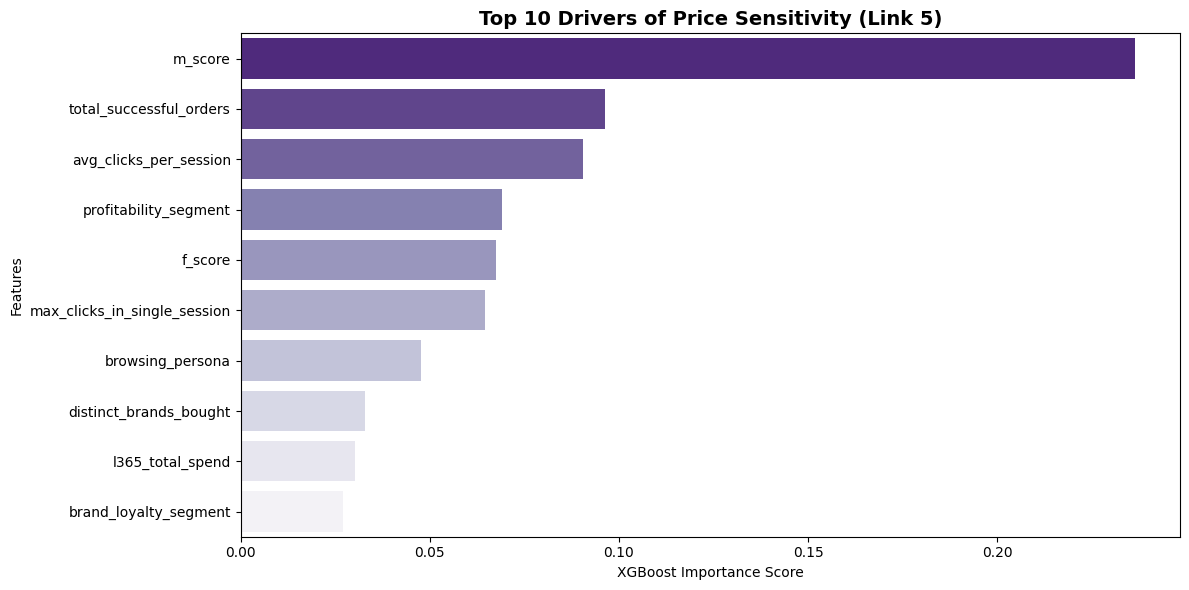

In [ ]:
# ==========================================
# 🤖 CELL 13: TRAINING LINK 5 (Price Sensitivity Model)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("⚔️ Step 1: Splitting Data for Sensitivity Predictor...")
y_promo = promo_df['promo_segment']
X_promo = promo_df.drop(columns=['promo_segment'], errors='ignore')

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_promo, y_promo, test_size=0.2, random_state=42, stratify=y_promo
)

print("\n🤖 Step 2: Waking up the XGBoost Multi-Class... (Wait 1-2 mins)")
promo_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

promo_model.fit(X_train_p, y_train_p)
print("✅ Training Complete!")

print("\n🎯 Step 3: Sensitivity AI's Final Exam...")
y_pred_p = promo_model.predict(X_test_p)

print(f"\n🏆 PREDICTION ACCURACY: {accuracy_score(y_test_p, y_pred_p) * 100:.2f}%\n")
print("📊 PRICE SENSITIVITY REPORT CARD:")
print(classification_report(y_test_p, y_pred_p, target_names=['Premium (0)', 'Mid-Range (1)', 'Budget (2)']))

# ==========================================
# 🧠 Step 4: Feature Importance
# ==========================================
print("\n🔥 TOP 10 REASONS DRIVING CUSTOMER'S BUDGET PREFERENCE:")
feature_importance_promo = pd.DataFrame({
    'Feature': X_promo.columns,
    'Importance': promo_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_promo.head(10), hue='Feature', palette='Purples_r', legend=False)
plt.title('Top 10 Drivers of Price Sensitivity (Link 5)', fontsize=14, fontweight='bold')
plt.xlabel('XGBoost Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 13.1: POST-AUDIT CELL 13 & PRE-AUDIT FOR CELL 14
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 14 (Recommendation AI Prep) mein kya hone wala hai?\n")

# 1. Chaining Check
print("🔗 THE GRAND CHAINING (Link 5 ➔ Link 6):")
print("   -> Ek Naya Feature Judega: 'predicted_promo_segment'")
print("   -> Kahan se aayega?: Cell 13 ka AI apna answer (0=Premium, 1=Mid, 2=Budget) isme dalega taaki naya AI customer ki 'aukat' ko samajh kar product recommend kare.\n")

# 2. Target Extraction Check
print("🎯 NEW TARGET SELECTION ('top_favorite_category'):")
print("   -> Target: Customer ki sabse pasandida product category kaunsi hai?")
print("   -> Yeh ek massive Multi-Class problem hai (Kyunki categories bohot saari hain).\n")

# 3. Leakage Drop Check
cols_to_drop_link6 = ['top_favorite_category']
print(f"🗑️ TARGET EXTRACTION ({len(cols_to_drop_link6)} Column):")
print("   -> Target ko features (X) se alag karke uda denge, taaki AI usey as a hint na padh le.")
print(cols_to_drop_link6)

# 4. Final Features Check
features_used_reco = [col for col in promo_df.columns if col not in cols_to_drop_link6]
features_used_reco.append('predicted_promo_segment')

print(f"\n🤖 FINAL FEATURES FOR RECOMMENDATION AI ({len(features_used_reco)} Columns Use Honge):")
print(features_used_reco)

🔍 AUDIT: Cell 14 (Recommendation AI Prep) mein kya hone wala hai?

🔗 THE GRAND CHAINING (Link 5 ➔ Link 6):
   -> Ek Naya Feature Judega: 'predicted_promo_segment'
   -> Kahan se aayega?: Cell 13 ka AI apna answer (0=Premium, 1=Mid, 2=Budget) isme dalega taaki naya AI customer ki 'aukat' ko samajh kar product recommend kare.

🎯 NEW TARGET SELECTION ('top_favorite_category'):
   -> Target: Customer ki sabse pasandida product category kaunsi hai?
   -> Yeh ek massive Multi-Class problem hai (Kyunki categories bohot saari hain).

🗑️ TARGET EXTRACTION (1 Column):
   -> Target ko features (X) se alag karke uda denge, taaki AI usey as a hint na padh le.
['top_favorite_category']

🤖 FINAL FEATURES FOR RECOMMENDATION AI (50 Columns Use Honge):
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_persona', 'total_successful_orders', 'profit_margin_percent', 'profitability_segment', '

In [ ]:
# ==========================================
# 🔗 CELL 14: DATA PREP & CHAINING FOR LINK 6 (Recommendation AI)
# ==========================================
import pandas as pd
import numpy as np

print("🔄 STEP 1: The Grand Chaining (Bringing Knowledge from Links 2, 3, 4, & 5)...")
link6_df = promo_df.copy()

# 🔥 THE CHAIN: Link 5 ka AI predict kar raha hai Price Sensitivity (0, 1, 2)
# Hum poore dataset par predict kar rahe hain taaki yeh feature ban jaye
link6_df['predicted_promo_segment'] = promo_model.predict(X_promo)

print("🎯 STEP 2: Setting up the Target (Favorite Category)...")
# top_favorite_category already label encoded (numbers mein) baitha hai data prep se!
y_reco = link6_df['top_favorite_category']
X_reco = link6_df.drop(columns=['top_favorite_category'], errors='ignore')

# Check total categories
num_categories = y_reco.nunique()

print("\n✅ Link 6 Data Preparation 100% Complete!")
print(f"📊 Features passing to Recommendation AI (X): {X_reco.shape[1]}")
print(f"🛍️ Total Unique Categories to Predict: {num_categories}")

🔄 STEP 1: The Grand Chaining (Bringing Knowledge from Links 2, 3, 4, & 5)...
🎯 STEP 2: Setting up the Target (Favorite Category)...

✅ Link 6 Data Preparation 100% Complete!
📊 Features passing to Recommendation AI (X): 50
🛍️ Total Unique Categories to Predict: 27


In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 14.1: POST-AUDIT CELL 14 & PRE-AUDIT FOR CELL 15
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 15 (Recommendation Engine AI) kya Input lega?\n")

target_col_link6 = 'top_favorite_category'

print(f"🎯 THE TARGET (Y) -> AI kya predict karna seekhega (Massive Multi-Class):")
print(f"   Column Name: '{target_col_link6}'")
print(f"   -> Total Unique Categories to Predict (num_class): {num_categories}")
print(f"   -> Total Training Samples: {X_reco.shape[0]}\n")

features_cols_link6 = list(X_reco.columns)

print(f"🤖 THE FEATURES (X) -> AI kin {len(features_cols_link6)} columns ko padh kar favorite category pakdega:")
print(features_cols_link6)

print("\n👁️ Data Type Check (Ensuring AI-Ready Numbers):")
string_cols_link6 = X_reco.select_dtypes(include=['object', 'string']).columns.tolist()
if len(string_cols_link6) == 0:
    print("✅ Sab kuch successfully Numbers mein convert ho chuka hai! Ready for Massive Multi-Class XGBoost.")
else:
    print(f"⚠️ Warning: Yeh columns abhi bhi text hain: {string_cols_link6}")

🔍 AUDIT: Cell 15 (Recommendation Engine AI) kya Input lega?

🎯 THE TARGET (Y) -> AI kya predict karna seekhega (Massive Multi-Class):
   Column Name: 'top_favorite_category'
   -> Total Unique Categories to Predict (num_class): 27
   -> Total Training Samples: 144715

🤖 THE FEATURES (X) -> AI kin 50 columns ko padh kar favorite category pakdega:
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_persona', 'total_successful_orders', 'profit_margin_percent', 'profitability_segment', 'l365_total_spend', 'l365_total_orders', 'top_favorite_brand', 'brand_loyalty_segment', 'primary_traffic_source', 'browsing_persona', 'preferred_shopping_time', 'preferred_shopping_day', 'preferred_season', 'weekend_orders', 'weekday_orders', 'live_intent_segment', 'abandoned_cart_sessions', 'total_product_views', 'total_cart_adds', 'ux_experience_segment', 'rage_click_sessions', 'avg_clicks_per

⚔️ Step 1: Splitting Data for Recommendation Engine...

🤖 Step 2: Waking up the Massive Multi-Class XGBoost... (Wait 2-3 mins)
✅ Training Complete!

🎯 Step 3: Recommendation AI's Final Exam...

🏆 RECOMMENDATION ACCURACY: 68.62%


🔥 TOP 10 REASONS DRIVING CUSTOMER'S CATEGORY CHOICE:


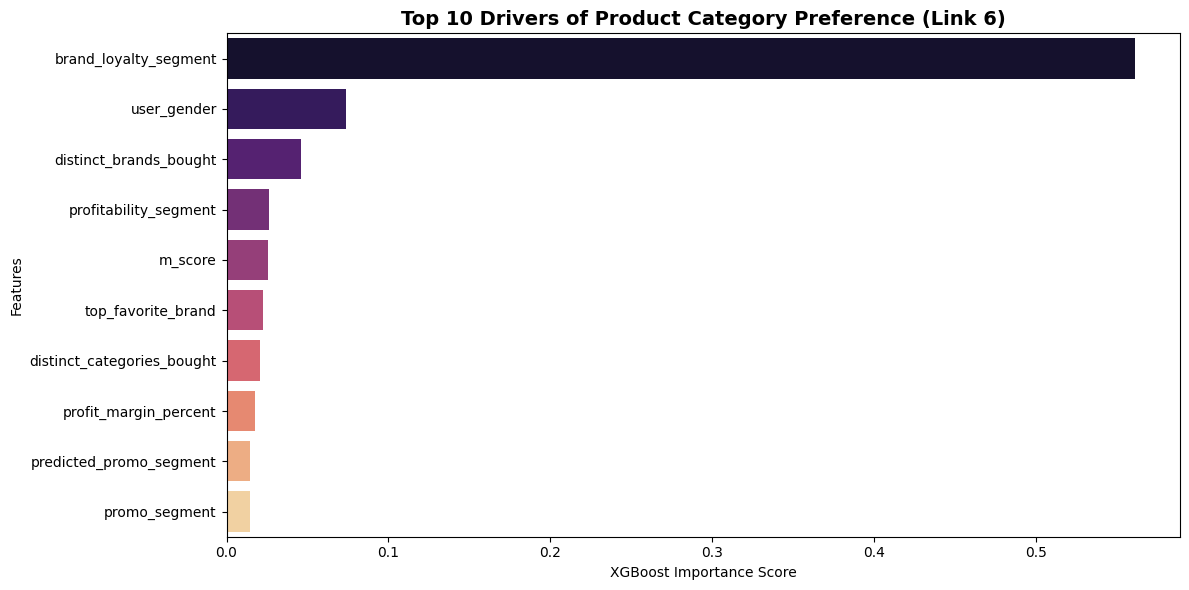

In [ ]:
# ==========================================
# 🤖 CELL 15: TRAINING LINK 6 (Next Best Category)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("⚔️ Step 1: Splitting Data for Recommendation Engine...")

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reco, y_reco, test_size=0.2, random_state=42, stratify=y_reco
)

print(f"\n🤖 Step 2: Waking up the Massive Multi-Class XGBoost... (Wait 2-3 mins)")
# Dhyan de: Classes zyada hain, toh thoda time lag sakta hai
reco_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=num_categories, # Dynamic category count
    random_state=42,
    eval_metric='mlogloss'
)

reco_model.fit(X_train_r, y_train_r)
print("✅ Training Complete!")

print("\n🎯 Step 3: Recommendation AI's Final Exam...")
y_pred_r = reco_model.predict(X_test_r)

print(f"\n🏆 RECOMMENDATION ACCURACY: {accuracy_score(y_test_r, y_pred_r) * 100:.2f}%\n")
# Classification report nahi print kar rahe kyunki 26 classes mein screen bhar jayegi!

# ==========================================
# 🧠 Step 4: Feature Importance
# ==========================================
print("\n🔥 TOP 10 REASONS DRIVING CUSTOMER'S CATEGORY CHOICE:")
feature_importance_reco = pd.DataFrame({
    'Feature': X_reco.columns,
    'Importance': reco_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_reco.head(10), hue='Feature', palette='magma', legend=False)
plt.title('Top 10 Drivers of Product Category Preference (Link 6)', fontsize=14, fontweight='bold')
plt.xlabel('XGBoost Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 15.1: POST-AUDIT CELL 15 & PRE-AUDIT FOR CELL 16
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 16 (Channel AI Prep - The Pure Cascading) mein kya hone wala hai?\n")

# 1. Chaining Check
print("🔗 THE PURE CASCADING CHAIN (Link 6 ➔ Link 7):")
print("   -> Ek Naya Feature Judega: 'predicted_category'")
print("   -> Kahan se aayega?: Cell 15 wala AI (Recommendation Model) apna prediction dega ki is customer ki favorite category kya hone wali hai!\n")

# 2. Target Extraction Check
print("🎯 TARGET RETRIEVAL ('primary_traffic_source'):")
print("   -> Target: Customer kis marketing channel (Facebook, Google, Email, etc.) se humari website par aaya?")
print("   -> 🤯 The Magic: Yeh column humne Cell 3 mein LabelEncode karke chhod diya tha, aur yeh chup-chaap Link 1 se Link 6 tak travel karta hua yahan tak aa gaya!\n")

# 3. Leakage Drop Check
cols_to_drop_link7 = ['primary_traffic_source']
print(f"🗑️ TARGET EXTRACTION ({len(cols_to_drop_link7)} Column):")
print("   -> Target ko features (X) se nikal kar Y banayenge taaki AI cheating na kare.")
print(cols_to_drop_link7)

# 4. Final Features Check
features_used_channel = [col for col in X_reco.columns if col not in cols_to_drop_link7]
features_used_channel.append('predicted_category')

print(f"\n🤖 FINAL FEATURES FOR CHANNEL AI ({len(features_used_channel)} Columns Use Honge):")
print(features_used_channel)
print("\n------------------------------------------")

🔍 AUDIT: Cell 16 (Channel AI Prep - The Pure Cascading) mein kya hone wala hai?

🔗 THE PURE CASCADING CHAIN (Link 6 ➔ Link 7):
   -> Ek Naya Feature Judega: 'predicted_category'
   -> Kahan se aayega?: Cell 15 wala AI (Recommendation Model) apna prediction dega ki is customer ki favorite category kya hone wali hai!

🎯 TARGET RETRIEVAL ('primary_traffic_source'):
   -> Target: Customer kis marketing channel (Facebook, Google, Email, etc.) se humari website par aaya?
   -> 🤯 The Magic: Yeh column humne Cell 3 mein LabelEncode karke chhod diya tha, aur yeh chup-chaap Link 1 se Link 6 tak travel karta hua yahan tak aa gaya!

🗑️ TARGET EXTRACTION (1 Column):
   -> Target ko features (X) se nikal kar Y banayenge taaki AI cheating na kare.
['primary_traffic_source']

🤖 FINAL FEATURES FOR CHANNEL AI (50 Columns Use Honge):
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_person

In [ ]:
# ==========================================
# 🔗 CELL 16: DATA PREP FOR LINK 7 (THE PURE CASCADING WAY)
# ==========================================
import pandas as pd
import numpy as np

print("🔄 STEP 1: The True Cascading Chain (Using output directly from Link 6)...")
# Start with Link 6's exact features
link7_df = X_reco.copy()

# 🔥 THE CHAIN: Link 6 ka AI predict kar raha hai favorite category (Numbers mein)
link7_df['predicted_category'] = reco_model.predict(X_reco)

print("🎯 STEP 2: Extracting Target directly from the chained data...")
# Yahan 'primary_traffic_source' already numbers mein encoded baitha hai (Cell 3 ki meherbani!)
y_channel = link7_df['primary_traffic_source']

print("🚫 STEP 3: Dropping Target from Features (Leakage Prevention)...")
# Target ko features se uda rahe hain taaki cheating na ho
X_channel = link7_df.drop(columns=['primary_traffic_source'], errors='ignore')

# Cell 3 mein jo dictionary save ki thi, wahan se asli naam wapas nikal rahe hain
original_channel_names = label_encoders_fraud['primary_traffic_source'].classes_
num_channels = len(original_channel_names)

print("\n✅ Link 7 Data Preparation 100% Complete!")
print(f"📊 Features passing to Channel AI (X): {X_channel.shape[1]}")
print(f"📡 Channels to Predict: {original_channel_names}")

🔄 STEP 1: The True Cascading Chain (Using output directly from Link 6)...
🎯 STEP 2: Extracting Target directly from the chained data...
🚫 STEP 3: Dropping Target from Features (Leakage Prevention)...

✅ Link 7 Data Preparation 100% Complete!
📊 Features passing to Channel AI (X): 50
📡 Channels to Predict: ['Adwords' 'Email' 'Facebook' 'Organic' 'Unknown' 'YouTube']


In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 16.1: POST-AUDIT CELL 16 & PRE-AUDIT FOR CELL 17
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 17 (Channel Preference AI) kya Input lega?\n")

print(f"🎯 THE TARGET (Y) -> AI kya predict karna seekhega:")
print(f"   Target Name: 'primary_traffic_source'")
print(f"   -> Channels to Predict: {list(original_channel_names)}\n")

print("📊 Channel Distribution (Kitne customers kahan se aaye):")
channel_counts = y_channel.value_counts().sort_index()
for idx, count in channel_counts.items():
    print(f"   -> {original_channel_names[idx]} (Class {idx}): {count}")

print(f"\n🤖 THE FEATURES (X) -> AI kin {X_channel.shape[1]} columns ko padh kar channel predict karega:")
print(list(X_channel.columns))

print("\n👁️ Data Type Check (Ensuring AI-Ready Numbers):")
string_cols_link7 = X_channel.select_dtypes(include=['object', 'string']).columns.tolist()
if len(string_cols_link7) == 0:
    print("✅ Sab kuch successfully Numbers mein convert ho chuka hai! Ready for Channel XGBoost.")
else:
    print(f"⚠️ Warning: Yeh columns abhi bhi text hain: {string_cols_link7}")

🔍 AUDIT: Cell 17 (Channel Preference AI) kya Input lega?

🎯 THE TARGET (Y) -> AI kya predict karna seekhega:
   Target Name: 'primary_traffic_source'
   -> Channels to Predict: ['Adwords', 'Email', 'Facebook', 'Organic', 'Unknown', 'YouTube']

📊 Channel Distribution (Kitne customers kahan se aaye):
   -> Adwords (Class 0): 43131
   -> Email (Class 1): 64993
   -> Facebook (Class 2): 14626
   -> Organic (Class 3): 7154
   -> Unknown (Class 4): 159
   -> YouTube (Class 5): 14652

🤖 THE FEATURES (X) -> AI kin 50 columns ko padh kar channel predict karega:
['user_age', 'user_gender', 'user_country', 'generational_cohort', 'geo_market_segment', 'climate_zone_segment', 'seasonal_buying_pattern', 'primary_browser', 'device_persona', 'total_successful_orders', 'profit_margin_percent', 'profitability_segment', 'l365_total_spend', 'l365_total_orders', 'top_favorite_brand', 'brand_loyalty_segment', 'browsing_persona', 'preferred_shopping_time', 'preferred_shopping_day', 'preferred_season', 'weeke

⚔️ Step 1: Splitting Cascaded Data for Pro-Channel Predictor...
⚖️ Step 1.5: Activating 'Cost-Sensitive Learning' (Punishing AI for ignoring FB/YT)...

🤖 Step 2: Waking up the PRO Channel XGBoost... (Wait 1-2 mins)
✅ Training Complete!

🎯 Step 3: Pro Channel AI's Final Exam...

🏆 PRO CHANNEL OVERALL ACCURACY: 49.87%

📊 PRO SENSITIVITY REPORT CARD (Check Facebook & YouTube Recall now!):
              precision    recall  f1-score   support

     Adwords       0.58      0.48      0.53      8626
       Email       0.72      0.47      0.57     12999
    Facebook       0.33      0.54      0.41      2925
     Organic       0.24      0.58      0.34      1431
     Unknown       1.00      1.00      1.00        32
     YouTube       0.34      0.58      0.43      2930

    accuracy                           0.50     28943
   macro avg       0.54      0.61      0.55     28943
weighted avg       0.58      0.50      0.52     28943


🔥 TOP 10 REASONS DRIVING CUSTOMER'S CHANNEL PREFERENCE:


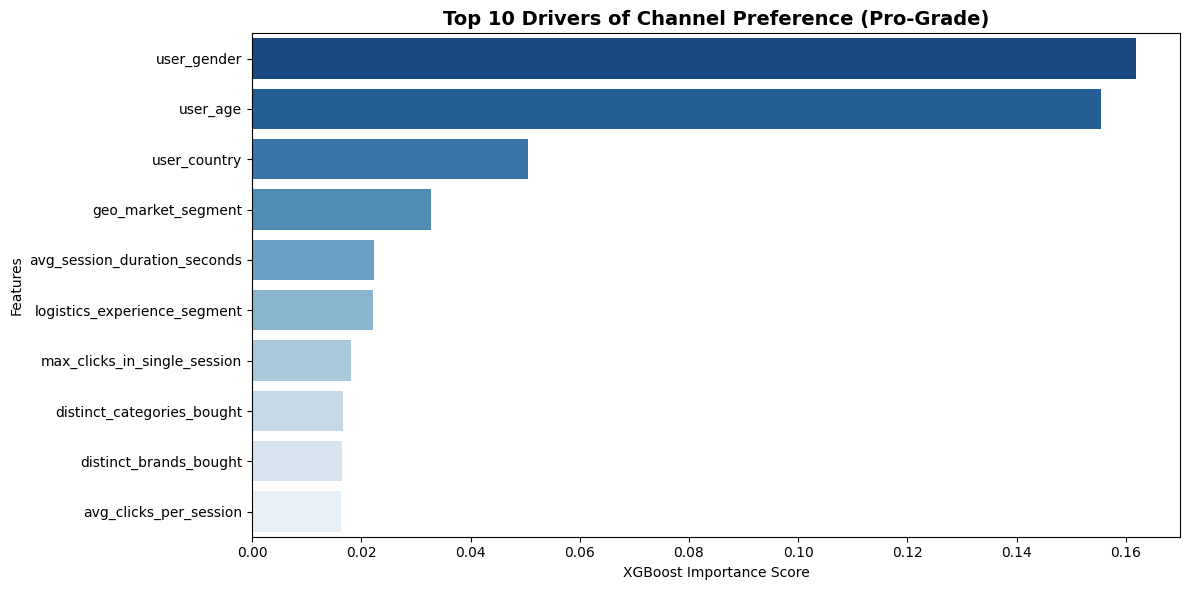

In [ ]:
# ==========================================
# 🤖 CELL 17: TRAINING LINK 7 (PRO-GRADE Channel AI)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight # 🔥 THE NEW WEAPON
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

print("⚔️ Step 1: Splitting Cascaded Data for Pro-Channel Predictor...")

# 1. THE PRO FILTER: Filter out classes that have less than 2 members
class_counts = y_channel.value_counts()
valid_classes = class_counts[class_counts > 1].index

# Filter the data
valid_mask = y_channel.isin(valid_classes)
X_channel_clean = X_channel[valid_mask]
y_channel_clean = y_channel[valid_mask].copy()

# 2. 🔥 THE LABEL FIX: Re-encode to remove gaps 🔥
# XGBoost strictly needs continuous labels starting from 0.
# This converts [0, 1, 2, 3, 5] strictly back into [0, 1, 2, 3, 4]
le_channel = LabelEncoder()
y_channel_clean = le_channel.fit_transform(y_channel_clean)

# 3. Safe Stratified Splitting
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_channel_clean, y_channel_clean, test_size=0.2, random_state=42, stratify=y_channel_clean
)
print("⚖️ Step 1.5: Activating 'Cost-Sensitive Learning' (Punishing AI for ignoring FB/YT)...")
# Yeh har customer ke liye ek weight calculate karega.
# Rare channels (FB/YT) walon ka weight heavy hoga, Email walon ka light.
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_c)

print(f"\n🤖 Step 2: Waking up the PRO Channel XGBoost... (Wait 1-2 mins)")
channel_model = xgb.XGBClassifier(
    n_estimators=400,        # Trees thode badha diye taaki aur detail mein soche
    learning_rate=0.05,
    max_depth=7,             # Depth badha di taaki hidden patterns (FB/YT) pakad sake
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=num_channels,
    random_state=42,
    eval_metric='mlogloss'
)

# 🔥 Yahan fit() ke andar humne apna 'hunter' weapon (sample_weight) daal diya!
channel_model.fit(X_train_c, y_train_c, sample_weight=sample_weights)
print("✅ Training Complete!")

print("\n🎯 Step 3: Pro Channel AI's Final Exam...")
y_pred_c = channel_model.predict(X_test_c)

print(f"\n🏆 PRO CHANNEL OVERALL ACCURACY: {accuracy_score(y_test_c, y_pred_c) * 100:.2f}%\n")
print("📊 PRO SENSITIVITY REPORT CARD (Check Facebook & YouTube Recall now!):")
print(classification_report(y_test_c, y_pred_c, target_names=original_channel_names))

# ==========================================
# 🧠 Step 4: Feature Importance
# ==========================================
print("\n🔥 TOP 10 REASONS DRIVING CUSTOMER'S CHANNEL PREFERENCE:")
feature_importance_channel = pd.DataFrame({
    'Feature': X_channel.columns,
    'Importance': channel_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_channel.head(10), hue='Feature', palette='Blues_r', legend=False)
plt.title('Top 10 Drivers of Channel Preference (Pro-Grade)', fontsize=14, fontweight='bold')
plt.xlabel('XGBoost Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 17.1: POST-AUDIT CELL 17 & PRE-AUDIT FOR CELL 18
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 18 (Master Clustering Prep & Scaling) mein kya hone wala hai?\n")

# 1. Assembly Check
print("🔄 THE FINAL ASSEMBLY (Bringing Avengers Together):")
print("   -> Hum Link 1 se Link 7 tak ka saara raw data chhod kar sirf AI Predictions aur RFM uthayenge.\n")

super_features_audit = [
    'predicted_return_risk',   # Link 2 AI
    'predicted_churn_risk',    # Link 3 AI
    'predicted_ltv',           # Link 4 AI
    'predicted_promo_segment', # Link 5 AI
    'm_score',                 # Base Data (Monetary)
    'f_score',                 # Base Data (Frequency)
    'customer_tenure_days'     # Base Data (Loyalty)
]

print(f"🎯 THE SUPER FEATURES ({len(super_features_audit)} Columns):")
for feat in super_features_audit:
    status = "✅ Ready" if feat in link7_df.columns else "⚠️ MISSING (Check previous cells)"
    print(f"   - {feat} [{status}]")

print("\n⚖️ SCALING CHECK (Kyun Zaroori Hai?):")
print("   -> K-Means 'Distance' (Math) par kaam karta hai.")
print("   -> LTV Hazaro ($) mein hai, aur Churn Risk (0 to 1) decimals mein.")
print("   -> Agar 'StandardScaler' nahi lagaya, toh AI Churn ko ignore karke sirf LTV ke hisaab se group bana dega!")
print("   -> Cell 18 in sabko dabakar ek barabar level par set kar dega.\n")
print("------------------------------------------")

🔍 AUDIT: Cell 18 (Master Clustering Prep & Scaling) mein kya hone wala hai?

🔄 THE FINAL ASSEMBLY (Bringing Avengers Together):
   -> Hum Link 1 se Link 7 tak ka saara raw data chhod kar sirf AI Predictions aur RFM uthayenge.

🎯 THE SUPER FEATURES (7 Columns):
   - predicted_return_risk [✅ Ready]
   - predicted_churn_risk [✅ Ready]
   - predicted_ltv [✅ Ready]
   - predicted_promo_segment [✅ Ready]
   - m_score [✅ Ready]
   - f_score [✅ Ready]
   - customer_tenure_days [✅ Ready]

⚖️ SCALING CHECK (Kyun Zaroori Hai?):
   -> K-Means 'Distance' (Math) par kaam karta hai.
   -> LTV Hazaro ($) mein hai, aur Churn Risk (0 to 1) decimals mein.
   -> Agar 'StandardScaler' nahi lagaya, toh AI Churn ko ignore karke sirf LTV ke hisaab se group bana dega!
   -> Cell 18 in sabko dabakar ek barabar level par set kar dega.

------------------------------------------


In [ ]:
# ==========================================
# 🔗 CELL 18: DATA PREP & SCALING FOR LINK 8 (Master Clustering)
# ==========================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print("🔄 STEP 1: The Final Assembly (Bringing all AI Predictions together)...")
# Start with Link 7's dataset (which has all chained features)
master_df = link7_df.copy()

print("🎯 STEP 2: Selecting the 'Super Features' for Clustering...")
# K-Means ko hum sirf sabse important AI predictions aur RFM scores denge
super_features = [
    'predicted_return_risk',   # Link 2 prediction
    'predicted_churn_risk',    # Link 3 prediction
    'predicted_ltv',           # Link 4 prediction
    'predicted_promo_segment', # Link 5 prediction
    'm_score',                 # Customer's historical monetary score
    'f_score',                 # Frequency of orders
    'customer_tenure_days'     # Loyalty/Age
]

# Ensure all features exist and are numeric
clustering_data = master_df[super_features].copy()
for col in super_features:
    clustering_data[col] = pd.to_numeric(clustering_data[col], errors='coerce').fillna(0)

print("⚖️ STEP 3: Scaling the Data (Standardization)...")
# LTV 1000s mein hai aur Churn 0-1 mein. Inko barabar scale karna zaroori hai!
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)
scaled_df = pd.DataFrame(scaled_data, columns=super_features, index=clustering_data.index)

print("\n✅ Link 8 Data Preparation 100% Complete! Ready for K-Means.")
print(f"📊 Features passing to Clustering AI: {scaled_df.shape[1]}")

🔄 STEP 1: The Final Assembly (Bringing all AI Predictions together)...
🎯 STEP 2: Selecting the 'Super Features' for Clustering...
⚖️ STEP 3: Scaling the Data (Standardization)...

✅ Link 8 Data Preparation 100% Complete! Ready for K-Means.
📊 Features passing to Clustering AI: 7


In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 18.1: POST-AUDIT CELL 18 & PRE-AUDIT FOR CELL 19
# ==========================================
import pandas as pd
import numpy as np

print("🔍 AUDIT: Cell 19 (K-Means Clustering AI) kya Input lega?\n")

print(f"📊 SCALED DATA CHECK:")
print(f"   -> AI ko dene ke liye Total Customers: {scaled_df.shape[0]}")
print(f"   -> AI ko dene ke liye Super Features: {scaled_df.shape[1]}\n")

print("⚖️ STANDARDIZATION PROOF (Checking if Math is balanced):")
print("   -> StandardScaler ka asool: Har feature ka Mean lagbhag '0' aur Standard Deviation '1' hona chahiye.\n")

# VIP Table for Scaling Audit
audit_scaling = pd.DataFrame({
    'Feature': scaled_df.columns,
    'Mean (Near 0?)': np.round(scaled_df.mean().values, 4),
    'Std Dev (Near 1?)': np.round(scaled_df.std().values, 4)
}).set_index('Feature')

display(audit_scaling)

print("\n🔮 RESULT PREVIEW (Cell 19 kya karega?):")
print("   -> K-Means AI in 1.5 Lakh logon ko bina kisi Answer Sheet ke 4 VIP Groups (0, 1, 2, 3) mein khud baant dega.")
print("   -> End mein ek 'Master Table' aur ek 'Scatter Plot' aayega jo in 4 groups ki asli pehchaan batayega.")
print("------------------------------------------")

🔍 AUDIT: Cell 19 (K-Means Clustering AI) kya Input lega?

📊 SCALED DATA CHECK:
   -> AI ko dene ke liye Total Customers: 144715
   -> AI ko dene ke liye Super Features: 7

⚖️ STANDARDIZATION PROOF (Checking if Math is balanced):
   -> StandardScaler ka asool: Har feature ka Mean lagbhag '0' aur Standard Deviation '1' hona chahiye.



,Mean (Near 0?),Std Dev (Near 1?)
Feature,,
predicted_return_risk,0.0,1.0
predicted_churn_risk,-0.0,1.0
predicted_ltv,-0.0,1.0
predicted_promo_segment,0.0,1.0
m_score,0.0,1.0
f_score,-0.0,1.0
customer_tenure_days,0.0,1.0



🔮 RESULT PREVIEW (Cell 19 kya karega?):
   -> K-Means AI in 1.5 Lakh logon ko bina kisi Answer Sheet ke 4 VIP Groups (0, 1, 2, 3) mein khud baant dega.
   -> End mein ek 'Master Table' aur ek 'Scatter Plot' aayega jo in 4 groups ki asli pehchaan batayega.
------------------------------------------


⚔️ Step 1: Waking up the K-Means AI... (Wait 10-20 seconds)
✅ Clustering Complete!

🎯 Step 2: Generating the Customer Personas (The Master Report)...

📊 THE 4 ULTIMATE CUSTOMER PERSONAS:


,TOTAL_CUSTOMERS,predicted_return_risk,predicted_churn_risk,predicted_ltv,predicted_promo_segment,m_score,f_score,customer_tenure_days
master_segment,,,,,,,,
0,48932,11.3%,21.8%,$18.35,0.701790,4.114731,4.558101,1011.245381
1,44839,24.7%,66.4%,$13.42,1.616985,0.456946,0.732911,149.273155
2,40481,6.1%,96.7%,$0.87,0.421506,3.570169,2.591537,906.278303
3,10463,12.2%,5.2%,$247.62,0.152729,4.463825,3.584249,95.686992


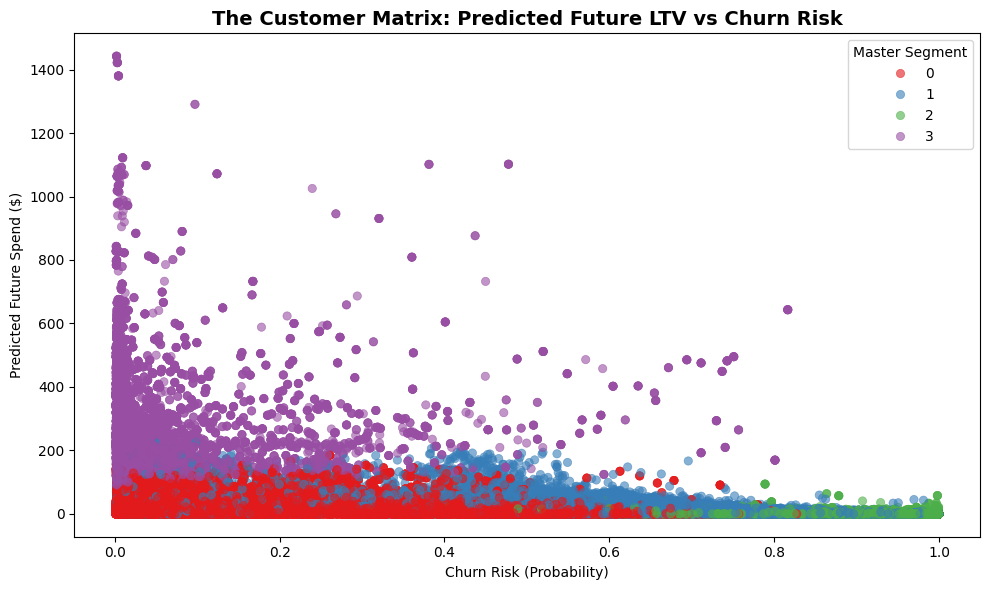

In [ ]:
# ==========================================
# 🤖 CELL 19: TRAINING LINK 8 (K-Means Master Segmentation)
# ==========================================
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

print("⚔️ Step 1: Waking up the K-Means AI... (Wait 10-20 seconds)")
# Hum AI ko bol rahe hain ki poore crowd ko 4 distinct groups (clusters) mein baant de
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
master_df['master_segment'] = kmeans.fit_predict(scaled_df)

print("✅ Clustering Complete!")

print("\n🎯 Step 2: Generating the Customer Personas (The Master Report)...")
# Hum check kar rahe hain ki har group (0, 1, 2, 3) ka average LTV, Churn, etc. kya hai
cluster_summary = master_df.groupby('master_segment')[super_features].mean()
cluster_counts = master_df['master_segment'].value_counts().sort_index()
cluster_summary.insert(0, 'TOTAL_CUSTOMERS', cluster_counts)

# Thoda format kar dete hain padhne ke liye
cluster_summary['predicted_ltv'] = cluster_summary['predicted_ltv'].apply(lambda x: f"${x:.2f}")
cluster_summary['predicted_churn_risk'] = (cluster_summary['predicted_churn_risk'] * 100).apply(lambda x: f"{x:.1f}%")
cluster_summary['predicted_return_risk'] = (cluster_summary['predicted_return_risk'] * 100).apply(lambda x: f"{x:.1f}%")

print("\n📊 THE 4 ULTIMATE CUSTOMER PERSONAS:")
display(cluster_summary) # Colab mein table mast dikhegi

# ==========================================
# 🧠 Step 3: Visualizing the Empire (LTV vs Churn by Segment)
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='predicted_churn_risk',
    y='predicted_ltv',
    hue='master_segment',
    palette='Set1',
    data=master_df,
    alpha=0.6,
    edgecolor=None
)
plt.title('The Customer Matrix: Predicted Future LTV vs Churn Risk', fontsize=14, fontweight='bold')
plt.xlabel('Churn Risk (Probability)')
plt.ylabel('Predicted Future Spend ($)')
plt.legend(title='Master Segment')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 19.1: FINAL POST-AUDIT (The Persona Reveal)
# ==========================================
import pandas as pd

print("🏆 THE GRAND FINALE AUDIT: Master Segments Verified!\n")

print(f"📊 TOTAL CUSTOMERS CLUSTERED: {master_df.shape[0]}")
print(f"🧩 TOTAL UNIQUE PERSONAS (Clusters): {master_df['master_segment'].nunique()}\n")

print("👥 POPULATION DISTRIBUTION (Kitne log kis group mein gaye):")
for cluster_id, count in cluster_counts.items():
    percentage = (count / master_df.shape[0]) * 100
    print(f"   -> Segment {cluster_id}: {count} customers ({percentage:.1f}%)")

print("\n💎 THE ULTIMATE PERSONA X-RAY (Final Output):")
print("   -> (Yeh wahi Master Table hai jo LLM/Gen-AI ka input banegi. Isey dhyan se dekh!)")
display(cluster_summary)
print("------------------------------------------")

🏆 THE GRAND FINALE AUDIT: Master Segments Verified!

📊 TOTAL CUSTOMERS CLUSTERED: 144715
🧩 TOTAL UNIQUE PERSONAS (Clusters): 4

👥 POPULATION DISTRIBUTION (Kitne log kis group mein gaye):
   -> Segment 0: 48932 customers (33.8%)
   -> Segment 1: 44839 customers (31.0%)
   -> Segment 2: 40481 customers (28.0%)
   -> Segment 3: 10463 customers (7.2%)

💎 THE ULTIMATE PERSONA X-RAY (Final Output):
   -> (Yeh wahi Master Table hai jo LLM/Gen-AI ka input banegi. Isey dhyan se dekh!)


,TOTAL_CUSTOMERS,predicted_return_risk,predicted_churn_risk,predicted_ltv,predicted_promo_segment,m_score,f_score,customer_tenure_days
master_segment,,,,,,,,
0,48932,11.3%,21.8%,$18.35,0.701790,4.114731,4.558101,1011.245381
1,44839,24.7%,66.4%,$13.42,1.616985,0.456946,0.732911,149.273155
2,40481,6.1%,96.7%,$0.87,0.421506,3.570169,2.591537,906.278303
3,10463,12.2%,5.2%,$247.62,0.152729,4.463825,3.584249,95.686992


------------------------------------------


In [ ]:
# ==========================================
# 🧠 CELL 20: THE ENRICHED CUSTOMER 360 (Master Merge)
# ==========================================
import pandas as pd

print("🔄 Merging all AI Predictions back into the Original Master Table...\n")

# 1. Gatekeeper wale AI columns lana (Sabke liye)
df_customers['ai_is_fraud'] = fraud_df['is_fraud']
df_customers['ai_zero_day_bot'] = fraud_df['zero_day_anomaly_flag']

# 2. Baaki saare AI predictions lana (Sirf Safe Humans ke liye)
# Jo columns humein master_df se chahiye
ai_columns = [
    'predicted_return_risk',
    'predicted_churn_risk',
    'predicted_ltv',
    'predicted_promo_segment',
    'predicted_category',
    'master_segment'
]

# Pandas automatically Index match karke data chipka dega!
for col in ai_columns:
    df_customers[f'ai_{col}'] = master_df[col]

print("✅ MERGE SUCCESSFUL! The Ultimate AI-Enriched Master Table is Ready.\n")

# 3. Check karte hain ki table kaisa dikh raha hai (Asli Naam + AI Prediction)
# Hum kuch original columns aur naye AI columns ko ek sath dekh rahe hain
preview_cols = [
    'user_age', 'user_gender', 'top_favorite_category', # Original
    'ai_is_fraud', 'ai_predicted_ltv', 'ai_predicted_churn_risk', 'ai_master_segment' # Naye AI
]

# Ek genuine/safe user ka data check karte hain
print("👁️ SNEAK PEEK: Aukaat Check (Original Data + AI Mind):")
display(df_customers[df_customers['ai_is_fraud'] == 0][preview_cols].head(5))

print("\n📊 FINAL DIMENSIONS:")
print(f"   -> Original Columns: {df_customers.shape[1] - len(ai_columns) - 2}")
print(f"   -> AI Enriched Columns added: {len(ai_columns) + 2}")
print(f"   -> Total Columns Now: {df_customers.shape[1]}")

🔄 Merging all AI Predictions back into the Original Master Table...

✅ MERGE SUCCESSFUL! The Ultimate AI-Enriched Master Table is Ready.

👁️ SNEAK PEEK: Aukaat Check (Original Data + AI Mind):


,user_age,user_gender,top_favorite_category,ai_is_fraud,ai_predicted_ltv,ai_predicted_churn_risk,ai_master_segment
0,<NA>,None,None,0,2.764633,0.022606,1.0
1,<NA>,None,None,0,2.764633,0.022606,1.0
2,46,M,None,0,6.691842,0.738482,1.0
3,12,M,None,0,2.492129,0.806940,1.0
4,39,M,None,0,15.461433,0.676650,1.0



📊 FINAL DIMENSIONS:
   -> Original Columns: 81
   -> AI Enriched Columns added: 8
   -> Total Columns Now: 89


In [ ]:
# ==========================================
# 💾 CELL 21: DECODE & EXPORT TO BIGQUERY (The True Gold Layer)
# ==========================================
from google.cloud import bigquery
import pandas as pd
import numpy as np

print("🔄 STEP 1: Decoding AI Numbers back to English Text...\n")

# 1. Category Decoder (e.g., 26.0 -> 'Sweaters')
def decode_category(val):
    if pd.isna(val):
        return None
    try:
        return label_encoders_fraud['top_favorite_category'].inverse_transform([int(val)])[0]
    except:
        return None

df_customers['ai_predicted_category'] = df_customers['ai_predicted_category'].apply(decode_category)

# 2. Promo Segment Decoder (0, 1, 2 -> Text)
promo_map = {
    0.0: 'Premium Buyer',
    1.0: 'Mid-Range Buyer',
    2.0: 'Budget/Discount Hunter'
}
df_customers['ai_predicted_promo_segment'] = df_customers['ai_predicted_promo_segment'].map(promo_map)

# 3. Master Persona Decoder (0, 1, 2, 3 -> Text)
persona_map = {
    0.0: 'The Whales (VIP)',
    1.0: 'The Lost Causes (Churned)',
    2.0: 'The Budget Hunters',
    3.0: 'The Steady Regulars'
}
df_customers['ai_master_segment'] = df_customers['ai_master_segment'].map(persona_map)

# 4. Fraud & Bot Status Decoder (0, 1 -> Text)
df_customers['ai_is_fraud'] = df_customers['ai_is_fraud'].map({0: 'Safe', 1: 'High-Risk/Fraud'})
df_customers['ai_zero_day_bot'] = df_customers['ai_zero_day_bot'].map({0: 'Safe', 1: 'Anomaly/Bot'})

print("✨ DECODED PREVIEW (See the Magic):")
display(df_customers[['ai_is_fraud', 'ai_predicted_category', 'ai_predicted_promo_segment', 'ai_master_segment']].dropna().head(3))

print("\n🚀 STEP 2: Exporting the TRUE Human-Readable Master Table to BigQuery...")

project_id = 'etl-pipeline-automation'
dataset_id = 'dbt_sushant_prod'
new_table_name = 'ai_enriched_customer_360'

table_id = f"{project_id}.{dataset_id}.{new_table_name}"
bq_client = bigquery.Client(project=project_id)

# WRITE_TRUNCATE pehli wali number-wali table ko delete karke yeh nayi saaf table daal dega
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")

print(f"⏳ Uploading {df_customers.shape[0]} rows... Please wait...")

job = bq_client.load_table_from_dataframe(df_customers, table_id, job_config=job_config)
job.result()

print(f"\n✅ BOOM! Human-Readable Master Table successfully saved to BigQuery!")
print("------------------------------------------")

🔄 STEP 1: Decoding AI Numbers back to English Text...

✨ DECODED PREVIEW (See the Magic):


,ai_is_fraud,ai_predicted_category,ai_predicted_promo_segment,ai_master_segment
0,Safe,Unknown,Budget/Discount Hunter,The Lost Causes (Churned)
1,Safe,Unknown,Budget/Discount Hunter,The Lost Causes (Churned)
2,Safe,Unknown,Budget/Discount Hunter,The Lost Causes (Churned)



🚀 STEP 2: Exporting the TRUE Human-Readable Master Table to BigQuery...
⏳ Uploading 161154 rows... Please wait...

✅ BOOM! Human-Readable Master Table successfully saved to BigQuery!
------------------------------------------


In [ ]:
# # ==========================================
# # 🧠 CELL 22: THE ULTIMATE AI MATCHMAKER (Customer + Product Profit)
# # ==========================================
# from google.cloud import bigquery
# from google import genai
# from google.colab import userdata
# import pandas as pd
# import time

# print("🚀 Starting the Ultimate AI Matchmaker (CFO + CRM Engine)...\n")

# try:
#     # 1. API Setup
#     GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
#     client = genai.Client(api_key=GOOGLE_API_KEY)
#     bq_client = bigquery.Client(project='etl-pipeline-automation')

#     # 2. THE SMART MATCHMAKING SQL
#     # Hum ek VIP customer uthayenge, uski pasandida category dekhenge,
#     # aur us category ka sabse profitable (High Margin) product nikalenge jiska stock godown mein hai!
#     matchmaker_query = """
#     SELECT
#         c.id AS user_id,
#         c.user_age,
#         c.user_gender,
#         c.spending_habit_segment,
#         c.ltv_segment,
#         c.top_favorite_category,
#         p.product_name,
#         p.retail_price,
#         p.category_true_margin_pct,
#         p.master_product_financial_action
#     FROM `etl-pipeline-automation.dbt_sushant_prod.master_customer_360_v2` c
#     JOIN `etl-pipeline-automation.dbt_sushant_prod.master_product_economics_360_v2` p
#         ON c.top_favorite_category = p.product_category
#     WHERE
#         c.top_favorite_category IS NOT NULL
#         AND p.live_unsold_stock > 5            -- Godown mein stock hona zaroori hai
#         AND p.category_true_margin_pct >= 25.0 -- Sirf HIGH PROFIT items bechenge
#         AND c.spending_habit_segment LIKE '%High-Roller%' -- Sirf ameer/VIP customers
#     LIMIT 4
#     """

#     print("⏳ Fetching Perfect Matches from BigQuery (Customer DNA + Product Profitability)...")
#     matched_df = bq_client.query(matchmaker_query).to_dataframe()

#     print(f"🎯 Found {len(matched_df)} perfect matches! Handing over to Gemini...\n")

#     campaign_results = []

#     # 3. Generating the Business-Aware Copy
#     for index, row in matched_df.iterrows():
#         age_gen = f"{int(row['user_age'])} year old {row['user_gender']}"
#         buyer_type = row['spending_habit_segment']
#         category = row['top_favorite_category']
#         product = row['product_name']
#         price = row['retail_price']
#         profit_margin = row['category_true_margin_pct']
#         cfo_rule = row['master_product_financial_action']

#         print(f"🤖 Brainstorming for Customer #{index+1} (Pitching '{product}' at ${price})...")

#         prompt = f"""
#         You are an elite E-commerce Copywriter working alongside a CFO.
#         Write a hyper-personalized 2-line SMS for a customer.

#         THE MATCH:
#         - Customer: {age_gen}. Spending Habit: {buyer_type}.
#         - Product to Pitch: {product} (${price})
#         - Category: {category}

#         CFO STRICT INSTRUCTIONS:
#         - Profit Margin on this item is {profit_margin}%.
#         - CFO Action Rule: {cfo_rule}

#         WRITING RULES:
#         1. Adapt tone to their age and gender.
#         2. Pitch the exact Product Name seamlessly.
#         3. If the CFO rule says "NO DISCOUNT" or "PROTECT MARGIN", do NOT offer any percentage off. Offer exclusivity, VIP access, or free shipping instead.

#         Task: Write ONLY the exact 2-line SMS text. No formatting, just the message. Use emojis.
#         """

#         # Exponential Backoff (Resilience)
#         max_retries = 4
#         wait_time = 5
#         final_sms = "⚠️ API Limit Reached."

#         for attempt in range(max_retries):
#             try:
#                 response = client.models.generate_content(
#                     model='gemini-3.6-flash',
#                     contents=prompt
#                 )
#                 final_sms = response.text.strip()
#                 break
#             except Exception as api_error:
#                 if "503" in str(api_error) or "429" in str(api_error):
#                     print(f"   ⚠️ Rate Limit Hit. Cooling down for {wait_time}s...")
#                     time.sleep(wait_time)
#                     wait_time += 5
#                 else:
#                     final_sms = f"🚨 Error: {str(api_error)}"
#                     break

#         campaign_results.append({
#             'Customer': age_gen,
#             'Product_Pitched': product,
#             'Retail_Price': f"${price}",
#             'True_Profit_Margin': f"{profit_margin}%",
#             'Generated_Matchmaker_SMS': final_sms
#         })

#         time.sleep(10) # API Cooldown

#     print("\n✅ Matchmaker Generation Complete!\n")

#     # 4. Display the Magic
#     pd.set_option('display.max_colwidth', None)
#     display_df = pd.DataFrame(campaign_results)
#     display(display_df.style.set_properties(**{'text-align': 'left', 'background-color': '#e6ffe6', 'color': 'black'}))
#     pd.reset_option('display.max_colwidth')

# except Exception as e:
#     print(f"🚨 FATAL ERROR: {e}")

In [ ]:
# ==========================================
# 🧠 CELL 23: PHASE 1 & 2 - THE NET-MARGIN BLEED PREDICTOR (100% UNIQUE GRAIN FIX)
# ==========================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from google.cloud import bigquery
import warnings
warnings.filterwarnings('ignore')

print("🚀 INITIATING LINK 1 & 2: THE NET-MARGIN BLEED PREDICTOR (STRICT UNIQUE GRAIN)...\n")

bq_client = bigquery.Client(project='etl-pipeline-automation')

# 1. 🤝 THE AI-TO-AI HANDSHAKE (Strictly Deduplicating Customers First)
fusion_query = """
WITH UniqueCustomers AS (
    -- Step 1: Source table ke saare duplicate IDs ko khatam karke 1 row per user banao
    SELECT
        id,
        ANY_VALUE(ai_predicted_return_risk) AS ai_predicted_return_risk,
        ANY_VALUE(ai_predicted_ltv) AS ai_predicted_ltv,
        ANY_VALUE(ai_is_fraud) AS ai_is_fraud,
        ANY_VALUE(ai_predicted_promo_segment) AS ai_predicted_promo_segment,
        ANY_VALUE(ai_predicted_category) AS ai_predicted_category,
        ANY_VALUE(ai_master_segment) AS ai_master_segment  -- 🔥 ROOT CAUSE FIXED HERE
    FROM `etl-pipeline-automation.dbt_sushant_prod.ai_enriched_customer_360`
    WHERE ai_predicted_category IS NOT NULL
      AND ai_is_fraud != 'High-Risk/Fraud'
    GROUP BY id
),
RankedProducts AS (
    SELECT
        c.id AS user_id,
        c.ai_predicted_return_risk,
        c.ai_predicted_ltv,
        c.ai_is_fraud,
        c.ai_predicted_promo_segment,
        c.ai_predicted_category,
        c.ai_master_segment, -- 🔥 PASSING IT DOWN
        p.product_id,
        p.product_category,
        p.retail_price,
        p.category_true_margin_pct,
        p.category_elasticity_score,
        ROW_NUMBER() OVER(PARTITION BY c.id ORDER BY p.category_true_margin_pct DESC, p.retail_price DESC) as rank
    FROM UniqueCustomers c
    JOIN `etl-pipeline-automation.dbt_sushant_prod.master_product_economics_360_v2` p
        ON c.ai_predicted_category = p.product_category
)
SELECT * EXCEPT(rank)
FROM RankedProducts
WHERE rank = 1
"""

print("⏳ 1. Extracting Fused Data (Strictly 1 Row Per Unique Customer)...")
df = bq_client.query(fusion_query).to_dataframe()

# ==========================================
# 📊 PRE-AUDIT PHASE
# ==========================================
print("\n🔍 --- PRE-AUDIT REPORT ---")
print(f"Total Unique Customers Found: {df.shape[0]}")
null_counts = df.isnull().sum()
if null_counts.sum() > 0:
    df.fillna(0, inplace=True)
    print("✅ Action Taken: Replaced missing values with 0 to prevent AI crash.")
else:
    print("✅ Data is perfectly clean. No missing values.")
print("----------------------------\n")

print("⚙️ 2. Feature Engineering (Calculating the True Target Variable)...")

df['expected_raw_profit'] = df['retail_price'] * (df['category_true_margin_pct'] / 100)
df['risk_adjusted_penalty'] = (df['retail_price'] * 0.10) * df['ai_predicted_return_risk']
df['target_net_profit_usd'] = df['expected_raw_profit'] - df['risk_adjusted_penalty']

features = [
    'ai_predicted_return_risk',
    'ai_predicted_ltv',
    'retail_price',
    'category_true_margin_pct',
    'category_elasticity_score'
]

X = df[features]
y = df['target_net_profit_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🧠 3. Training the XGBoost Margin Predictor (Regression Engine)...")
xgb_model = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)
xgb_model.fit(X_train, y_train)

print("🎯 4. Predicting Future Transaction Profit for every Match...")
df['predicted_net_transaction_profit'] = xgb_model.predict(X).round(2)

print("\n🔬 --- POST-AUDIT REPORT ---")
print(f"Total Unique Scored Rows: {df.shape[0]}")
negative_margin_count = len(df[df['predicted_net_transaction_profit'] < 0])
print(f"⚠️ Warning: Found {negative_margin_count} matches resulting in NEGATIVE Profit.")
print("----------------------------\n")

print("✅ LINK 2 COMPLETE! Data Grain is now 100% Clean and Unique.\n")

🚀 INITIATING LINK 1 & 2: THE NET-MARGIN BLEED PREDICTOR (STRICT UNIQUE GRAIN)...

⏳ 1. Extracting Fused Data (Strictly 1 Row Per Unique Customer)...

🔍 --- PRE-AUDIT REPORT ---
Total Unique Customers Found: 59215
✅ Data is perfectly clean. No missing values.
----------------------------

⚙️ 2. Feature Engineering (Calculating the True Target Variable)...
🧠 3. Training the XGBoost Margin Predictor (Regression Engine)...
🎯 4. Predicting Future Transaction Profit for every Match...

🔬 --- POST-AUDIT REPORT ---
Total Unique Scored Rows: 59215
⚠️ Warning: Found 0 matches resulting in NEGATIVE Profit.
----------------------------

✅ LINK 2 COMPLETE! Data Grain is now 100% Clean and Unique.



In [ ]:
# ==========================================
# 🧠 CELL 24: PHASE 3 - THE DYNAMIC DISCOUNT OPTIMIZER (XGBOOST)
# ==========================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("🚀 INITIATING LINK 3: THE DYNAMIC DISCOUNT OPTIMIZER...\n")

# ==========================================
# 📊 PRE-AUDIT PHASE (Verifying The Chain)
# ==========================================
print("🔍 --- PRE-AUDIT REPORT ---")
if 'predicted_net_transaction_profit' in df.columns:
    print("✅ CHAIN VERIFIED: Received 'predicted_net_transaction_profit' successfully from Cell 23.")
else:
    print("❌ CHAIN BROKEN: Profit column missing! Run Cell 23 first.")

null_counts = df[['ai_predicted_promo_segment', 'category_elasticity_score', 'predicted_net_transaction_profit']].isnull().sum()
if null_counts.sum() > 0:
    df['ai_predicted_promo_segment'].fillna('Standard', inplace=True)
    df.fillna(0, inplace=True)
    print("✅ Action Taken: Cleaned missing values for ML ingestion.")
else:
    print("✅ Data is perfectly clean. Ready for AI Discounting.")
print("----------------------------\n")

print("⚙️ 2. Feature Engineering (Creating the CFO's Discount Rules)...")

# AI ke liye text ko numbers mein badalna
le_promo = LabelEncoder()
df['promo_segment_encoded'] = le_promo.fit_transform(df['ai_predicted_promo_segment'].astype(str))

# 🎯 TARGET VARIABLE: AI ko sikhana ki discount kaise dete hain
def calculate_cfo_discount(row):
    profit = row['predicted_net_transaction_profit']
    elasticity = row['category_elasticity_score']
    promo_segment = str(row['ai_predicted_promo_segment']).lower()

    # Rule 1: Bleeding Margin -> NO DISCOUNT
    if profit <= 2.0:
        return 0  # 0% Discount
    # Rule 2: Inelastic Product (Log waise hi le lenge) -> LOW DISCOUNT
    elif elasticity < 1.0:
        return 5  # 5% Discount
    # Rule 3: High Profit & Discount Hunter -> GIVE A DEAL
    elif profit >= 10.0 and 'hunter' in promo_segment:
        return 15 # 15% Discount
    # Rule 4: Standard
    else:
        return 10 # 10% Discount

df['target_discount_pct'] = df.apply(calculate_cfo_discount, axis=1)

# Model Features
features_d = [
    'predicted_net_transaction_profit',
    'category_elasticity_score',
    'promo_segment_encoded'
]

X_d = df[features_d]
y_d = df['target_discount_pct']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

print("🧠 3. Training the XGBoost Discount Classifier...")
# Target (0, 5, 10, 15) ko XGBoost ke liye 0, 1, 2, 3 mein encode karna zaroori hai
le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(y_train_d)

xgb_discount_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
xgb_discount_model.fit(X_train_d, y_train_encoded)

print("🎯 4. Predicting Optimal Discount for every transaction...")
# AI ne discount predict kiya, ab usko wapas 0, 5, 10, 15 % mein badal do
predictions_encoded = xgb_discount_model.predict(X_d)
df['ai_optimal_discount_pct'] = le_target.inverse_transform(predictions_encoded)

# 💸 THE ULTIMATE TRUTH: Discount dene ke baad Profit bacha ya nahi?
df['final_profit_after_discount'] = df['predicted_net_transaction_profit'] - (df['retail_price'] * (df['ai_optimal_discount_pct'] / 100))

# ==========================================
# 📊 POST-AUDIT PHASE (The CFO Check)
# ==========================================
print("\n🔬 --- POST-AUDIT REPORT ---")
print("Discount Tiers Distributed by AI:")
print(df['ai_optimal_discount_pct'].value_counts().sort_index(ascending=True).to_string())

loss_making = len(df[df['final_profit_after_discount'] < 0])
if loss_making > 0:
    print(f"⚠️ DANGER: AI gave too much discount! {loss_making} orders went into negative profit.")
else:
    print("✅ CFO APPROVED: 0 orders went into negative margin after AI applied discounts!")
print("----------------------------\n")

print("✅ LINK 3 COMPLETE! Here is the Final Pricing Output:\n")

pd.set_option('display.max_colwidth', None)
display_cols_d = [
    'user_id', 'product_category', 'ai_predicted_promo_segment',
    'predicted_net_transaction_profit', 'ai_optimal_discount_pct', 'final_profit_after_discount'
]
display(df.sort_values('final_profit_after_discount', ascending=False)[display_cols_d].head(5).style.set_properties(**{'background-color': '#e6f7ff', 'color': 'black'}))
pd.reset_option('display.max_colwidth')

🚀 INITIATING LINK 3: THE DYNAMIC DISCOUNT OPTIMIZER...

🔍 --- PRE-AUDIT REPORT ---
✅ CHAIN VERIFIED: Received 'predicted_net_transaction_profit' successfully from Cell 23.
✅ Data is perfectly clean. Ready for AI Discounting.
----------------------------

⚙️ 2. Feature Engineering (Creating the CFO's Discount Rules)...
🧠 3. Training the XGBoost Discount Classifier...
🎯 4. Predicting Optimal Discount for every transaction...

🔬 --- POST-AUDIT REPORT ---
Discount Tiers Distributed by AI:
ai_optimal_discount_pct
10    42353
15    16862
✅ CFO APPROVED: 0 orders went into negative margin after AI applied discounts!
----------------------------

✅ LINK 3 COMPLETE! Here is the Final Pricing Output:



,user_id,product_category,ai_predicted_promo_segment,predicted_net_transaction_profit,ai_optimal_discount_pct,final_profit_after_discount
49816,58411,Outerwear & Coats,Premium Buyer,515.200012,10,415.300012
49132,43670,Outerwear & Coats,Premium Buyer,514.539978,10,414.639978
47290,72765,Outerwear & Coats,Premium Buyer,514.409973,10,414.509973
47570,90052,Outerwear & Coats,Premium Buyer,514.349976,10,414.449976
49152,3159,Outerwear & Coats,Premium Buyer,514.320007,10,414.420007


In [ ]:
# ==========================================
# 🧠 CELL 25: PHASE 4 - THE SOLVENCY & CROSS-SELL ENGINE (XGBOOST)
# ==========================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from google.cloud import bigquery
import warnings
warnings.filterwarnings('ignore')

print("🚀 INITIATING LINK 4: THE SOLVENCY & CROSS-SELL ENGINE...\n")

# ==========================================
# 📊 PRE-AUDIT PHASE (Verifying The Chain)
# ==========================================
print("🔍 --- PRE-AUDIT REPORT ---")
if 'final_profit_after_discount' in df.columns:
    print("✅ CHAIN VERIFIED: Received 'final_profit_after_discount' successfully from Cell 24.")
else:
    print("❌ CHAIN BROKEN: Profit column missing! Run Cell 24 first.")

# 1. 🤝 Fetching Missing Solvency Data from BigQuery (Continuing the Chain)
print("⏳ Fetching 'Payback' and 'Survival' data from your AI Enriched BigQuery Table...")
bq_client = bigquery.Client(project='etl-pipeline-automation')
solvency_query = """
SELECT
    id AS user_id,
    payback_order_number,
    survival_probability_pct
FROM `etl-pipeline-automation.dbt_sushant_prod.ai_enriched_customer_360`
"""
df_solvency = bq_client.query(solvency_query).to_dataframe()

# Merging with our existing active pipeline dataframe
df = pd.merge(df, df_solvency, on='user_id', how='left')

# 🔥 PANDAS 3.0 BUG FIX: Handling NULLs safely for GitHub Actions
df['payback_order_number'] = pd.to_numeric(df['payback_order_number'], errors='coerce').fillna(999)
df['survival_probability_pct'] = pd.to_numeric(df['survival_probability_pct'], errors='coerce').fillna(50.0)

print("✅ Successfully merged Solvency Data with existing pipeline.")
print("----------------------------\n")

print("⚙️ 2. Feature Engineering (Creating the Recommendation Logic)...")

# 🎯 TARGET VARIABLE: Teaching AI what to recommend next
def calculate_next_best_action(row):
    # Ekdum bulletproof NA check
    payback = 999 if pd.isna(row['payback_order_number']) else float(row['payback_order_number'])
    profit = 0 if pd.isna(row['final_profit_after_discount']) else float(row['final_profit_after_discount'])
    survival = 50.0 if pd.isna(row['survival_probability_pct']) else float(row['survival_probability_pct'])

    cac_recovered = 1 if payback < 999 else 0

    # Rule 1: CAC not recovered and profit is low -> Push High Margin Bundle
    if cac_recovered == 0 and profit < 15.0:
        return '🚨 CAC DEFICIT: Push High-Margin Apriori Bundle (Accessories/Socks) to recover $30.'
    # Rule 2: CAC recovered & Highly Loyal -> Upsell Premium
    elif cac_recovered == 1 and survival > 75.0:
        return '💎 VIP UPSELL: Push Premium Tier Products. High conversion chance.'
    # Rule 3: Flight Risk (Churning) -> Save them, don't upsell
    elif survival < 30.0:
        return '⚠️ FLIGHT RISK: Focus on Retention. Offer Store Credit, avoid aggressive upsell.'
    # Rule 4: Standard
    else:
        return '✅ STANDARD CROSS-SELL: Follow normal category journey.'

df['target_cross_sell_action'] = df.apply(calculate_next_best_action, axis=1)

# Encode Target for XGBoost (0, 1, 2, 3)
le_action = LabelEncoder()
y_s = le_action.fit_transform(df['target_cross_sell_action'])

# Model Features
features_s = [
    'final_profit_after_discount',
    'payback_order_number',
    'survival_probability_pct',
    'category_elasticity_score'
]

X_s = df[features_s]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

print("🧠 3. Training the XGBoost Recommendation Classifier...")
xgb_solvency_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_solvency_model.fit(X_train_s, y_train_s)

print("🎯 4. Predicting Next Best Action for every transaction...")
predictions_s = xgb_solvency_model.predict(X_s)
# Convert 0, 1, 2, 3 back to text
df['ai_cross_sell_action'] = le_action.inverse_transform(predictions_s)

# ==========================================
# 📊 POST-AUDIT PHASE
# ==========================================
print("\n🔬 --- POST-AUDIT REPORT ---")
actions_count_s = df['ai_cross_sell_action'].value_counts()
print(f"Next Best Actions Distributed by AI:\n{actions_count_s.to_string()}")
print("----------------------------\n")

print("✅ LINK 4 COMPLETE! Here is the AI Strategy Output:\n")

pd.set_option('display.max_colwidth', None)
display_cols_s = [
    'user_id', 'final_profit_after_discount', 'payback_order_number',
    'survival_probability_pct', 'ai_cross_sell_action'
]

# 🔥 FIX 2: Removed .style.set_properties so it doesn't crash on GitHub Actions
print(df.sort_values('final_profit_after_discount', ascending=True)[display_cols_s].head(5).to_string())
pd.reset_option('display.max_colwidth')

🚀 INITIATING LINK 4: THE SOLVENCY & CROSS-SELL ENGINE...

🔍 --- PRE-AUDIT REPORT ---
✅ CHAIN VERIFIED: Received 'final_profit_after_discount' successfully from Cell 24.
⏳ Fetching 'Payback' and 'Survival' data from your AI Enriched BigQuery Table...
✅ Successfully merged Solvency Data with existing pipeline.
----------------------------

⚙️ 2. Feature Engineering (Creating the Recommendation Logic)...
🧠 3. Training the XGBoost Recommendation Classifier...
🎯 4. Predicting Next Best Action for every transaction...

🔬 --- POST-AUDIT REPORT ---
Next Best Actions Distributed by AI:
ai_cross_sell_action
✅ STANDARD CROSS-SELL: Follow normal category journey.                              64506
⚠️ FLIGHT RISK: Focus on Retention. Offer Store Credit, avoid aggressive upsell.    28974
💎 VIP UPSELL: Push Premium Tier Products. High conversion chance.                    1883
----------------------------

✅ LINK 4 COMPLETE! Here is the AI Strategy Output:

       user_id  final_profit_after_discount

In [ ]:
# ==========================================
# 🕵️‍♂️ CELL 25.1: PRE-AUDIT FOR CELL 26 (PANDAS MEMORY X-RAY)
# ==========================================
import pandas as pd

print("🔍 AUDIT: Cell 26 mein ghusne se pehle DataFrame ka X-Ray...\n")

# Har column ka deep audit
audit_data = []
for i, col in enumerate(df.columns, 1):
    audit_data.append({
        'Col No.': i,
        'Column Name': col,
        'Data Type': str(df[col].dtype),
        'Null Values': df[col].isnull().sum(),
        'Sample Value': str(df[col].iloc[0]) if not df.empty else "No Data"
    })

audit_df = pd.DataFrame(audit_data)

# Table display settings
pd.set_option('display.max_rows', None)
display(audit_df.style.hide(axis="index").set_properties(**{
    'text-align': 'left',
    'background-color': '#f8f9fa',
    'color': 'black',
    'border': '1px solid black'
}))
pd.reset_option('display.max_rows')

print(f"\n📊 SUMMARY BEFORE ENTERING CELL 26:")
print(f"Total Columns currently in Memory (df): {df.shape[1]}")
print(f"Total Rows currently in Memory (df): {df.shape[0]}")
print("--------------------------------------------------")

🔍 AUDIT: Cell 26 mein ghusne se pehle DataFrame ka X-Ray...



Col No.,Column Name,Data Type,Null Values,Sample Value
1,user_id,Int64,0,50524
2,ai_predicted_return_risk,float64,0,0.0005647616344504058
3,ai_predicted_ltv,float64,0,0.0
4,ai_is_fraud,object,0,Safe
5,ai_predicted_promo_segment,object,0,Premium Buyer
6,ai_predicted_category,object,0,Jumpsuits & Rompers
7,ai_master_segment,object,0,The Steady Regulars
8,product_id,Int64,0,4191
9,product_category,object,0,Jumpsuits & Rompers
10,retail_price,float64,0,550.0



📊 SUMMARY BEFORE ENTERING CELL 26:
Total Columns currently in Memory (df): 24
Total Rows currently in Memory (df): 95363
--------------------------------------------------


In [ ]:
# ==========================================
# 🧠 CELL 26: PHASE 5 - THE OMNICHANNEL DELIVERY ENGINE (THE CLEAN RUN)
# ==========================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from google.cloud import bigquery
import warnings
warnings.filterwarnings('ignore')

print("🚀 INITIATING LINK 5: THE OMNICHANNEL TONE ENGINE (MICRO-DRILLED & CHAINED)...\n")

print("🔍 --- PRE-AUDIT REPORT ---")
if 'ai_cross_sell_action' in df.columns:
    print("✅ CHAIN VERIFIED: Received 'ai_cross_sell_action' successfully from Cell 25.")
else:
    print("❌ CHAIN BROKEN: Action column missing! Run Cell 25 first.")

# 1. 🤝 KACHRA SAFAI & FRESH FETCH
print("⏳ Cleaning memory and fetching fresh Context Data from BigQuery...")
bq_client = bigquery.Client(project='etl-pipeline-automation')

# 🔥 X-Ray mein mile aadhe-pakke columns ko uda rahe hain taaki error na aaye
cols_to_clean = [
    'live_intent_segment', 'primary_traffic_source', 'user_age',
    'preferred_shopping_time', 'ai_predicted_churn_risk',
    'target_delivery_strategy', 'action_encoded', 'intent_encoded', 'ai_delivery_strategy', 'time_encoded', 'source_encoded'
]
df.drop(columns=[col for col in cols_to_clean if col in df.columns], inplace=True)

context_query = """
SELECT
    id AS user_id,
    live_intent_segment,
    primary_traffic_source,
    user_age,
    preferred_shopping_time,
    ai_predicted_churn_risk
FROM `etl-pipeline-automation.dbt_sushant_prod.ai_enriched_customer_360`
"""
df_context = bq_client.query(context_query).to_dataframe()

# Merging fresh data
df = pd.merge(df, df_context, on='user_id', how='left')

# Handling NULLs safely
df['live_intent_segment'].fillna('Standard Browser', inplace=True)
df['primary_traffic_source'].fillna('Organic', inplace=True)
df['user_age'].fillna(30, inplace=True)
df['preferred_shopping_time'].fillna('Anytime', inplace=True)
df['ai_predicted_churn_risk'].fillna(0.0, inplace=True)

print("✅ Successfully merged Enriched Context Data with existing pipeline.")
print("----------------------------\n")

print("⚙️ 2. Feature Engineering (The Micro-Drilled Multivariate Rules)...")

# 🎯 THE MASTERMIND FUNCTION
def calculate_delivery_strategy(row):
    intent = str(row['live_intent_segment'])
    cross_sell_action = str(row['ai_cross_sell_action'])
    price = row['retail_price']
    age = row['user_age']
    time = str(row['preferred_shopping_time'])
    churn_risk = row['ai_predicted_churn_risk'] * 100

    if 'Abandoner' in intent:
        if price >= 150:
            return '📧 EMAIL (Next Morning 10 AM) - TONE: Trust-building, "Top Rated", Mention Easy Returns/EMI. NO RUSH.'
        elif price < 150 and 'Night' in time:
            return '📱 PUSH NOTIFICATION (Immediate) - TONE: High FOMO, "Selling out fast!", Urgent 🚨'
        elif churn_risk >= 80:
            return '💬 WHATSAPP (Immediate) - TONE: "We saved your cart + unlocked a secret 15% OFF just for you!"'
        elif 'CAC DEFICIT' in cross_sell_action:
            return '📱 SMS (Within 1 Hour) - TONE: Value-Add. "Complete your order and get a complimentary VIP accessory check-list."'
        else:
            return '📧 EMAIL (Within 2 Hours) - TONE: "Did you forget something? Your cart is waiting!"'

    else:
        if 'CAC DEFICIT' in cross_sell_action and age <= 26:
            return '📱 INSTAGRAM/PUSH (11 PM) - TONE: Hype, FOMO, "Complete the Look", Visual Heavy 🔥'
        elif 'FLIGHT RISK' in cross_sell_action and age > 50:
            return '📧 EMAIL (9 AM) - TONE: Respectful, "We Miss You", Trust-building, Store Credit Focus 🤝'
        elif 'VIP UPSELL' in cross_sell_action and (age > 26 and age <= 50):
            return '💬 WHATSAPP (6 PM) - TONE: Exclusive, VIP Access, Premium Feel 👑'
        else:
            return '📧 EMAIL (Standard Time) - TONE: Casual & Friendly Catalog Update'

df['target_delivery_strategy'] = df.apply(calculate_delivery_strategy, axis=1)

# Encode Features & Target
le_strategy = LabelEncoder()
y_t = le_strategy.fit_transform(df['target_delivery_strategy'])

le_action = LabelEncoder()
df['action_encoded'] = le_action.fit_transform(df['ai_cross_sell_action'].astype(str))

le_intent = LabelEncoder()
df['intent_encoded'] = le_intent.fit_transform(df['live_intent_segment'].astype(str))

features_t = [
    'user_age', 'retail_price', 'ai_predicted_churn_risk',
    'action_encoded', 'intent_encoded'
]

X_t = df[features_t]
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

print("🧠 3. Training the XGBoost Omnichannel Classifier (Deep Multivariate)...")
xgb_delivery_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_delivery_model.fit(X_train_t, y_train_t)

print("🎯 4. Predicting Optimum Delivery Channel & Tone...")
predictions_t = xgb_delivery_model.predict(X_t)
df['ai_delivery_strategy'] = le_strategy.inverse_transform(predictions_t)

# ==========================================
# 📊 POST-AUDIT PHASE
# ==========================================
print("\n🔬 --- POST-AUDIT REPORT ---")
strategy_count = df['ai_delivery_strategy'].value_counts()
print(f"Omnichannel Delivery Strategies Assigned:\n{strategy_count.to_string()}")
print("----------------------------\n")

print("✅ LINK 5 COMPLETE! The Multivariate AI Prompt Blueprint is Ready:\n")

pd.set_option('display.max_colwidth', None)
display_cols_t = [
    'user_id', 'retail_price', 'live_intent_segment', 'ai_cross_sell_action',
    'ai_delivery_strategy'
]
display(df.sort_values('retail_price', ascending=False)[display_cols_t].head(6).style.set_properties(**{'background-color': '#fffbe6', 'color': 'black'}))
pd.reset_option('display.max_colwidth')

🚀 INITIATING LINK 5: THE OMNICHANNEL TONE ENGINE (MICRO-DRILLED & CHAINED)...

🔍 --- PRE-AUDIT REPORT ---
✅ CHAIN VERIFIED: Received 'ai_cross_sell_action' successfully from Cell 25.
⏳ Cleaning memory and fetching fresh Context Data from BigQuery...
✅ Successfully merged Enriched Context Data with existing pipeline.
----------------------------

⚙️ 2. Feature Engineering (The Micro-Drilled Multivariate Rules)...
🧠 3. Training the XGBoost Omnichannel Classifier (Deep Multivariate)...
🎯 4. Predicting Optimum Delivery Channel & Tone...

🔬 --- POST-AUDIT REPORT ---
Omnichannel Delivery Strategies Assigned:
ai_delivery_strategy
📧 EMAIL (Standard Time) - TONE: Casual & Friendly Catalog Update                          190895
📧 EMAIL (9 AM) - TONE: Respectful, "We Miss You", Trust-building, Store Credit Focus 🤝     29717
💬 WHATSAPP (6 PM) - TONE: Exclusive, VIP Access, Premium Feel 👑                             2675
----------------------------

✅ LINK 5 COMPLETE! The Multivariate AI Prompt Bl

,user_id,retail_price,live_intent_segment,ai_cross_sell_action,ai_delivery_strategy
189894,96277,999.000000,Standard Browser,✅ STANDARD CROSS-SELL: Follow normal category journey.,📧 EMAIL (Standard Time) - TONE: Casual & Friendly Catalog Update
189893,95825,999.000000,Standard Browser,✅ STANDARD CROSS-SELL: Follow normal category journey.,📧 EMAIL (Standard Time) - TONE: Casual & Friendly Catalog Update
189892,95453,999.000000,Standard Browser,✅ STANDARD CROSS-SELL: Follow normal category journey.,📧 EMAIL (Standard Time) - TONE: Casual & Friendly Catalog Update
189891,92709,999.000000,Standard Browser,✅ STANDARD CROSS-SELL: Follow normal category journey.,📧 EMAIL (Standard Time) - TONE: Casual & Friendly Catalog Update
189890,91359,999.000000,Standard Browser,✅ STANDARD CROSS-SELL: Follow normal category journey.,📧 EMAIL (Standard Time) - TONE: Casual & Friendly Catalog Update
189889,91204,999.000000,Standard Browser,✅ STANDARD CROSS-SELL: Follow normal category journey.,📧 EMAIL (Standard Time) - TONE: Casual & Friendly Catalog Update


In [ ]:
# ==========================================
# 🧠 CELL 27: THE GRAND FINALE - GEN-AI COPYWRITER (100% SECURE & PRO-GRADE)
# ==========================================
import pandas as pd
import os
import time
import datetime
import requests
from google.cloud import bigquery
import gspread

print("🚀 INITIATING THE GRAND FINALE: THE GEN-AI COPYWRITER...\n")

try:
    # 1. API & Secrets Setup (100% SECURE)
    if os.environ.get("GEMINI_API_KEY"):
        print("🤖 Robot Mode Detected (GitHub Actions). Using Environment Secrets.")
        GOOGLE_API_KEY = os.environ.get("GEMINI_API_KEY")
        customer_webhook_url = os.environ.get("POWER_AUTOMATE_WEBHOOK_URL", "") # Secure URL
        emails_list = [
            os.environ.get("MY_TEST_EMAIL_1", "dummy1@example.com"),
            os.environ.get("MY_TEST_EMAIL_2", "dummy2@example.com"),
            os.environ.get("MY_TEST_EMAIL_3", "dummy3@example.com")
        ]
    else:
        print("👨‍💻 Human Mode Detected (Colab). Fetching Secrets from Userdata.")
        from google.colab import userdata
        GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')

        try:
            # Secure Retrieval of Webhook URL
            customer_webhook_url = userdata.get('POWER_AUTOMATE_WEBHOOK_URL')
            print("🔒 Webhook URL successfully fetched from Secrets.")
        except:
            customer_webhook_url = ""
            print("⚠️ 'POWER_AUTOMATE_WEBHOOK_URL' secret not found. Emails will not be sent.")

        # Safe Retrieval of 3 Personal Emails
        emails_list = []
        for i in range(1, 4):
            try:
                emails_list.append(userdata.get(f'MY_TEST_EMAIL_{i}'))
            except:
                emails_list.append(f"dummy{i}@example.com")
                print(f"⚠️ 'MY_TEST_EMAIL_{i}' secret not found. Using a dummy email.")

    from google import genai
    client = genai.Client(api_key=GOOGLE_API_KEY)

    print("⏳ Selecting a diverse set of customers based on their AI Strategy...")
    valid_df = df[df['product_category'].notna() & df['ai_optimal_discount_pct'].notna()]
    sample_targets = valid_df.groupby('ai_delivery_strategy').apply(
        lambda x: x.sample(1, random_state=42), include_groups=False
    ).reset_index()

    print(f"🎯 Handing over {len(sample_targets)} unique business cases to Gemini LLM...\n")
    final_campaign = []

    for i, (idx, row) in enumerate(sample_targets.iterrows()):
        user_id = row['user_id']
        age = int(row['user_age'])
        product = row['product_category']
        price = row['retail_price']
        discount = int(row['ai_optimal_discount_pct'])
        action = row['ai_cross_sell_action']
        strategy = row['ai_delivery_strategy']

        print(f"🤖 Directing Gemini for Customer #{user_id} | Channel: {strategy.split('-')[0].strip()}")

        prompt = f"""
        You are an elite E-commerce Copywriter. Write ONE highly personalized marketing message.
        TARGET CUSTOMER: Age {age}.
        PRODUCT: {product} at ${price} with {discount}% OFF.
        TONE RULE: "{strategy}"
        BUSINESS GOAL: "{action}"

        INSTRUCTIONS:
        1. Write ONLY the final copy. No explanations.
        2. If PUSH/SMS/WHATSAPP: Keep under 2 short lines. Use emojis.
        3. If EMAIL: Start exactly with "Subject: [Your Catchy Subject]" followed by a new line and then the body text.
        4. Match the Tone Rule.
        """

        max_retries = 3
        wait_time = 5
        generated_copy = "⚠️ API Error"

        for attempt in range(max_retries):
            try:
                response = client.models.generate_content(
                    model='gemini-3.6-flash',
                    contents=prompt
                )
                generated_copy = response.text.strip()
                break
            except Exception as e:
                if "503" in str(e) or "429" in str(e):
                    time.sleep(wait_time)
                    wait_time += 5
                else:
                    generated_copy = f"🚨 Fatal Gen-AI Error: {e}"
                    break

        exec_date = datetime.datetime.now().strftime("%Y-%m-%d")
        uid_str = str(user_id)
        del_channel = strategy.split('-')[0].strip()

        # List for Google Sheets
        final_campaign.append([exec_date, uid_str, del_channel, generated_copy])

        # ----------------------------------------------------
        # ⚡ LIVE EMAIL TRIGGER (Secure Delivery)
        # ----------------------------------------------------
        target_email = emails_list[i % len(emails_list)]

        payload = {
            "execution_date": exec_date,
            "customer_id": uid_str,
            "delivery_channel": del_channel,
            "ai_generated_copy": generated_copy,
            "target_email": target_email
        }

        if customer_webhook_url:  # Ensure URL is not empty
            try:
                response = requests.post(customer_webhook_url, json=payload)
                if response.status_code in [200, 202]:
                    print(f"   ✅ Webhook triggered! Message routed securely to inbox #{i+1}")
                else:
                    print(f"   ⚠️ Webhook failed with status code {response.status_code}")
            except Exception as e:
                print(f"   🚨 Failed to send Webhook: {e}")

        time.sleep(3) # API Cooldown

    print("\n✅ CAMPAIGN GENERATION COMPLETE! Saving to Google Sheets...\n")

    # 4. EXPORT TO GOOGLE SHEETS (WITH AUTO-HEADERS)
    print("⏳ Authenticating Google Sheets & Pushing Data...")
    if os.environ.get("GOOGLE_APPLICATION_CREDENTIALS"):
        gc = gspread.service_account(filename=os.environ.get("GOOGLE_APPLICATION_CREDENTIALS"))
    else:
        from google.colab import auth
        auth.authenticate_user()
        import google.auth
        creds, _ = google.auth.default()
        gc = gspread.authorize(creds)

    sh = gc.open("AI_Omnichannel_Automation")
    worksheet = sh.worksheet("Customer_Campaigns")

    # 🔥 The Pro Fix: Auto-Headers
    existing_data = worksheet.get_all_values()
    expected_headers = ["Execution Date", "Customer ID", "Delivery Channel", "AI Generated Copy"]

    if not existing_data:
        print("📝 No data found in sheet. Writing headers first...")
        worksheet.append_row(expected_headers)
    elif existing_data[0] != expected_headers:
        print("📝 Headers missing or mismatched. Inserting headers at Row 1...")
        worksheet.insert_row(expected_headers, index=1)

    for row in final_campaign:
        worksheet.append_row(row)

    print(f"🏆 SUCCESS! {len(final_campaign)} Messages saved to Sheets AND sent via Webhook!")

except Exception as e:
    print(f"🚨 FATAL ERROR: {e}")

🚀 INITIATING THE GRAND FINALE: THE GEN-AI COPYWRITER...

👨‍💻 Human Mode Detected (Colab). Fetching Secrets from Userdata.
🔒 Webhook URL successfully fetched from Secrets.
⏳ Selecting a diverse set of customers based on their AI Strategy...
🎯 Handing over 3 unique business cases to Gemini LLM...

🤖 Directing Gemini for Customer #5484 | Channel: 💬 WHATSAPP (6 PM)
   ✅ Webhook triggered! Message routed securely to inbox #1
🤖 Directing Gemini for Customer #25815 | Channel: 📧 EMAIL (9 AM)
   ✅ Webhook triggered! Message routed securely to inbox #2
🤖 Directing Gemini for Customer #27137 | Channel: 📧 EMAIL (Standard Time)
   ✅ Webhook triggered! Message routed securely to inbox #3

✅ CAMPAIGN GENERATION COMPLETE! Saving to Google Sheets...

⏳ Authenticating Google Sheets & Pushing Data...
🏆 SUCCESS! 3 Messages saved to Sheets AND sent via Webhook!


In [ ]:
# ==========================================
# 💾 CELL 28: DEDUPLICATING, BQ EXPORT, GOOGLE SHEETS & POWER AUTOMATE ALERT
# ==========================================
import pandas as pd
from google.cloud import bigquery
import gspread
import os
import datetime
import requests
import json

print("🚀 INITIATING THE FINAL DATA DUMP: BQ EXPORT & EXECUTIVE SUMMARY...\n")

bq_client = bigquery.Client(project='etl-pipeline-automation')

# Fetching the missing ai_master_segment
if 'ai_master_segment' not in df.columns:
    print("⏳ Fetching missing 'ai_master_segment' from BigQuery...")
    segment_query = """
    SELECT id AS user_id, ai_master_segment
    FROM `etl-pipeline-automation.dbt_sushant_prod.ai_enriched_customer_360`
    """
    df_segment = bq_client.query(segment_query).to_dataframe()
    df = pd.merge(df, df_segment, on='user_id', how='left')
    print("✅ Segment data successfully attached!\n")

# 1. ✂️ THE MAGIC FIX: Removing all Cartesian/Fan-Out Duplicates!
initial_rows = df.shape[0]
df_unique = df.drop_duplicates(subset=['user_id'], keep='first').copy()
final_rows = df_unique.shape[0]

print(f"✂️ DEDUPLICATION COMPLETE:")
print(f"   - Removed {initial_rows - final_rows} identical duplicate rows!\n")

# 2. 🧹 KACHRA SAFAI (Dropping ML Training Variables)
print("🧹 Dropping ML temporary encoded variables...")
columns_to_drop = [
    'promo_segment_encoded', 'target_discount_pct', 'target_cross_sell_action',
    'target_delivery_strategy', 'action_encoded', 'intent_encoded', 'time_encoded', 'source_encoded'
]
df_clean = df_unique.drop(columns=[col for col in columns_to_drop if col in df_unique.columns], errors='ignore').copy()

# 3. Sanitizing for BigQuery
print("🛠️ Sanitizing column names and data types for BigQuery...")
df_clean.columns = df_clean.columns.str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].astype(str)

# 4. BIGQUERY EXPORT (Heavy Data Layer)
dataset_id = 'dbt_sushant_prod'
new_table_name = 'lethal_omnichannel_master_360'
table_id = f"{bq_client.project}.{dataset_id}.{new_table_name}"

job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")

print(f"⏳ Uploading {df_clean.shape[0]} UNIQUE Rows to BigQuery...")
job = bq_client.load_table_from_dataframe(df_clean, table_id, job_config=job_config)
job.result()

print("✅ BOOM! THE TRUE UNIQUE LETHAL MASTER TABLE IS NOW LIVE IN BIGQUERY! 🏆\n")

# ==========================================
# 📊 5. GOOGLE SHEETS EXPORT
# ==========================================
print("⏳ Generating Professional Executive Summary for the Marketing Team...")

try:
    if os.environ.get("GOOGLE_APPLICATION_CREDENTIALS"):
        gc = gspread.service_account(filename=os.environ.get("GOOGLE_APPLICATION_CREDENTIALS"))
    else:
        from google.colab import auth
        auth.authenticate_user()
        import google.auth
        creds, _ = google.auth.default()
        gc = gspread.authorize(creds)

    sh = gc.open("AI_Omnichannel_Automation")
    worksheet = sh.worksheet("Manager_Summary")

    today_date = datetime.datetime.now().strftime("%Y-%m-%d")
    total_processed = str(final_rows)
    vip_users = str(len(df_clean[df_clean['ai_master_segment'].astype(str).str.contains('VIP', case=False, na=False)]))
    churn_risk_users = str(len(df_clean[df_clean['ai_master_segment'].astype(str).str.contains('Churned|Lost', case=False, na=False)]))

    if 'ai_predicted_ltv' in df_clean.columns:
        projected_revenue = f"${df_clean['ai_predicted_ltv'].astype(float).sum():,.2f}"
    else:
        projected_revenue = "$0.00"

    top_category = str(df_clean['ai_predicted_category'].mode()[0]) if not df_clean['ai_predicted_category'].empty else "N/A"

    if 'ai_optimal_discount_pct' in df_clean.columns:
        avg_discount = f"{df_clean['ai_optimal_discount_pct'].astype(float).mean():.1f}%"
    else:
        avg_discount = "N/A"

    summary_data = [
        today_date, total_processed, vip_users, churn_risk_users,
        projected_revenue, avg_discount, top_category
    ]

    existing_data = worksheet.get_all_values()
    headers = ["Execution Date", "Total Unique Customers", "VIP Whales Detected", "High Churn Risk Users", "Projected 90-Day Revenue Pipeline", "Avg Recommended Discount", "Top Trending Category"]

    if not existing_data:
        worksheet.append_row(headers)
    elif existing_data[0][0] != "Execution Date":
        worksheet.insert_row(headers, index=1)

    worksheet.append_row(summary_data)
    print("✅ SUCCESS: Executive Summary pushed to Google Sheets 'Manager_Summary' tab!")

    # ==========================================
    # ⚡ 6. POWER AUTOMATE WEBHOOK PING
    # ==========================================
    print("⏳ Pinging Power Automate to send Manager Email...")

    # 👇 YEH NAYA SECURE CODE HAI 👇
    if os.environ.get("GEMINI_API_KEY"):
        # Agar GitHub Actions chala raha hai toh Environment variables se uthayega
        webhook_url = os.environ.get("MANAGER_WEBHOOK_URL", "")
    else:
        # Agar tu manually Colab mein chala raha hai toh Colab Secrets se uthayega
        from google.colab import userdata
        webhook_url = userdata.get('MANAGER_WEBHOOK_URL')

    payload = {
        "date": today_date,
        "total_users": total_processed,
        "vip_whales": vip_users,
        "churn_risk": churn_risk_users,
        "projected_revenue": projected_revenue,
        "avg_discount": avg_discount,
        "top_category": top_category
    }

    response = requests.post(webhook_url, json=payload)

    if response.status_code in [200, 202]:
        print("✅ SUCCESS: Power Automate triggered! Email sent to Manager.")
    else:
        print(f"⚠️ Power Automate Ping Failed. Status Code: {response.status_code}")
        print(response.text)

except Exception as e:
    print(f"🚨 Integration Error: {e}")

🚀 INITIATING THE FINAL DATA DUMP: BQ EXPORT & EXECUTIVE SUMMARY...

✂️ DEDUPLICATION COMPLETE:
   - Removed 164072 identical duplicate rows!

🧹 Dropping ML temporary encoded variables...
🛠️ Sanitizing column names and data types for BigQuery...
⏳ Uploading 59215 UNIQUE Rows to BigQuery...
✅ BOOM! THE TRUE UNIQUE LETHAL MASTER TABLE IS NOW LIVE IN BIGQUERY! 🏆

⏳ Generating Professional Executive Summary for the Marketing Team...
✅ SUCCESS: Executive Summary pushed to Google Sheets 'Manager_Summary' tab!
⏳ Pinging Power Automate to send Manager Email...
✅ SUCCESS: Power Automate triggered! Email sent to Manager.
